In [1]:
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from lightkurve import search_targetpixelfile
from lightkurve import prf

import os
import glob
import pandas as pd
from astroquery.mast import Catalogs

import sys
from raDec2Pix import raDec2Pix
from transitDiffImage import keplerDiffImage as kdi
import keplerApp as app


In [2]:
koi = 109.01
koiName = "KOI-109.01"
quarterList = [1, 2, 3, 4, 6, 7, 8, 10, 11, 12, 14, 15, 16]
# starList = [0, 1, 2, 3, 4, 5, 6, 7, 8]
starList = [0, 1, 2]


In [3]:
standardDepth = 1e-3

In [4]:
rdp = raDec2Pix.raDec2PixClass()
koiData = kdi.get_koi_data(koi)

transitModelFileName = "../../kepler/so/pixelModeling/Kepler_TCE_DV_DR25_wget.bat"
transitModel = kdi.get_dv_model(koiData, transitModelFileName)

mjdOffset = 54832.5

allDiffImage = []
allDiffImageFlat = np.array([])
allDiffImageSigma = []
allDiffImageSigmaFlat = np.array([])
allSimDiffImage = {}
allSimDiffImageFlat = {}
for s in range(len(starList)):
    allSimDiffImage[s] = []
    allSimDiffImageFlat[s] = np.array([])
    
quarterDataList = []
haveQuarters = []
for quarter in quarterList:
    tpf = search_targetpixelfile('KIC ' + str(koiData["kepid"]), quarter = quarter, exptime="long").download();
    if tpf is None:
        print("TPF not found in quarter " + str(quarter))
        continue;
    quarterData = {}
    quarterData["quarter"] = quarter
    # extract the data fields from the tpf object without the hdu field for serialization
    quarterData["tpf"] = tpf;

    quarterData["extent"] = (quarterData["tpf"].column-0.5, quarterData["tpf"].column + quarterData["tpf"].shape[2]-0.5, quarterData["tpf"].row-0.5, quarterData["tpf"].row + quarterData["tpf"].shape[1]-0.5)

    # BKJD = BJD-2454833.0, MJD = JD-2400000.5, so MJD = BKJD + 2454833.0 - 2400000.5 = BKJD + 54832.5
    quarterData["meanMjd"] = np.mean(quarterData["tpf"].time.bkjd) + mjdOffset  
    print("meanMjd = " + str(quarterData["meanMjd"]))

    diffImageObject = kdi.keplerDiffImage(tpf, koiData)

    # Find the transits and compute the difference image averaged over the transits.  Draw them.
    quarterData["diffImageData"] = diffImageObject.find_transits(transitModel)
    
    diffImage = quarterData["diffImageData"]["diffImage"] - np.nanmin(quarterData["diffImageData"]["diffImage"])
    nanMask = ~np.isnan(diffImage.flatten())
    allDiffImage.append(diffImage)
    allDiffImageFlat = np.append(allDiffImageFlat, diffImage.flatten()[nanMask])
    
    diffImageSigma = quarterData["diffImageData"]["diffImageSigma"]
    allDiffImageSigma.append(diffImageSigma)
    allDiffImageSigmaFlat = np.append(allDiffImageSigmaFlat, diffImageSigma.flatten()[nanMask])

    quarterData["diffImageObject"] = diffImageObject
    quarterData["gaiaCatalog"] = kdi.get_gaia_catalog(quarterData["tpf"], quarterData["meanMjd"], rdp)

    # Set up image modeling with the Kepler PRF
    kepprf = prf.KeplerPRF(channel=quarterData["tpf"].channel, shape=quarterData["diffImageData"]["meanOutTransit"].shape,
                         column=quarterData["tpf"].column-0.5, row=quarterData["tpf"].row-0.5)
    prfExtent = (kepprf.column, kepprf.column + kepprf.shape[1], kepprf.row, kepprf.row + kepprf.shape[0])

    simOutTransitImage = np.flipud(app.make_simulated_image(quarterData["gaiaCatalog"], kepprf))
    for star in starList:
        simInTransitImage = np.flipud(app.make_simulated_image(quarterData["gaiaCatalog"], kepprf, starIndex = star, depth = standardDepth))
        simDiffImage = simOutTransitImage-simInTransitImage
        allSimDiffImage[star].append(simDiffImage)
        allSimDiffImageFlat[star] = np.append(allSimDiffImageFlat[star], simDiffImage.flatten()[nanMask])

    
    quarterDataList.append(quarterData)
    haveQuarters.append(quarter)

{'dec': 39.803928,
 'disposition': 'FALSE POSITIVE',
 'durationHours': 3.9015,
 'epoch': 132.86482,
 'galacticLatitude': 9.566526347808628,
 'kepid': 4752451,
 'kepmag': 12.385,
 'koiNum': 'K00109.01',
 'observedDepth': 0.00020119999999999998,
 'otherPlanetList': [],
 'period': 6.41496453,
 'ra': 293.45428,
 'tceNum': 1}
../../kepler/so/pixelModeling/Kepler_TCE_DV_DR25_wget.bat
<_io.BufferedReader name=80>
wget -O 'kplr004752451-20160128150956_dvt.fits' 'http://exoplanetarchive.ipac.caltech.edu:80/data/ETSS//KeplerDV/005/711/99/kplr004752451-20160128150956_dvt.fits' -a search_14666024.log


/opt/anaconda3/lib/python3.11/site-packages/astropy/io/fits/fitsrec.py:700: UserWarning: Field 12 has a repeat count of 0 in its format code, indicating an empty field.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:382: RuntimeWarning: Mean of empty slice
  meanInTransit = np.nanmean(self.tpf.flux[inTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:383: RuntimeWarning: Mean of empty slice
  meanInTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[inTransitIndices,::-1,:].value**2, axis=0)/len(inTransitIndices))
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:384: RuntimeWarning: Mean of empty slice
  meanOutTransit = np.nanmean(self.tpf.flux[outTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:385: RuntimeWarning: Mean of empty slice
  meanOutTransitSigma = np.sqrt(np.n

meanMjd = 54980.73855766733
INFO: Query finished. [astroquery.utils.tap.core]
meanMjd = 55046.69721241444


/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:382: RuntimeWarning: Mean of empty slice
  meanInTransit = np.nanmean(self.tpf.flux[inTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:383: RuntimeWarning: Mean of empty slice
  meanInTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[inTransitIndices,::-1,:].value**2, axis=0)/len(inTransitIndices))
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:384: RuntimeWarning: Mean of empty slice
  meanOutTransit = np.nanmean(self.tpf.flux[outTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:385: RuntimeWarning: Mean of empty slice
  meanOutTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[outTransitIndices,::-1,:].value**2, axis=0)/len(outTransitIndices))


INFO: Query finished. [astroquery.utils.tap.core]
meanMjd = 55137.35680840534


...

TPF not found in quarter 14
meanMjd = 56255.17804906914


/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:382: RuntimeWarning: Mean of empty slice
  meanInTransit = np.nanmean(self.tpf.flux[inTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:383: RuntimeWarning: Mean of empty slice
  meanInTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[inTransitIndices,::-1,:].value**2, axis=0)/len(inTransitIndices))
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:384: RuntimeWarning: Mean of empty slice
  meanOutTransit = np.nanmean(self.tpf.flux[outTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:385: RuntimeWarning: Mean of empty slice
  meanOutTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[outTransitIndices,::-1,:].value**2, axis=0)/len(outTransitIndices))


INFO: Query finished. [astroquery.utils.tap.core]
meanMjd = 56352.37463478432


/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:382: RuntimeWarning: Mean of empty slice
  meanInTransit = np.nanmean(self.tpf.flux[inTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:383: RuntimeWarning: Mean of empty slice
  meanInTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[inTransitIndices,::-1,:].value**2, axis=0)/len(inTransitIndices))
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:384: RuntimeWarning: Mean of empty slice
  meanOutTransit = np.nanmean(self.tpf.flux[outTransitIndices,::-1,:].value, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/transitDiffImage/keplerDiffImage.py:385: RuntimeWarning: Mean of empty slice
  meanOutTransitSigma = np.sqrt(np.nanmean(self.tpf.flux_err[outTransitIndices,::-1,:].value**2, axis=0)/len(outTransitIndices))


INFO: Query finished. [astroquery.utils.tap.core]


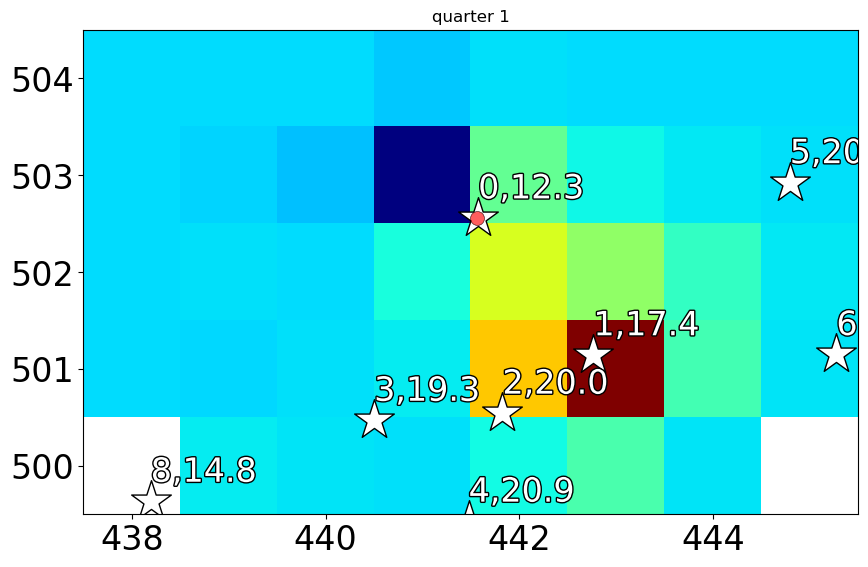

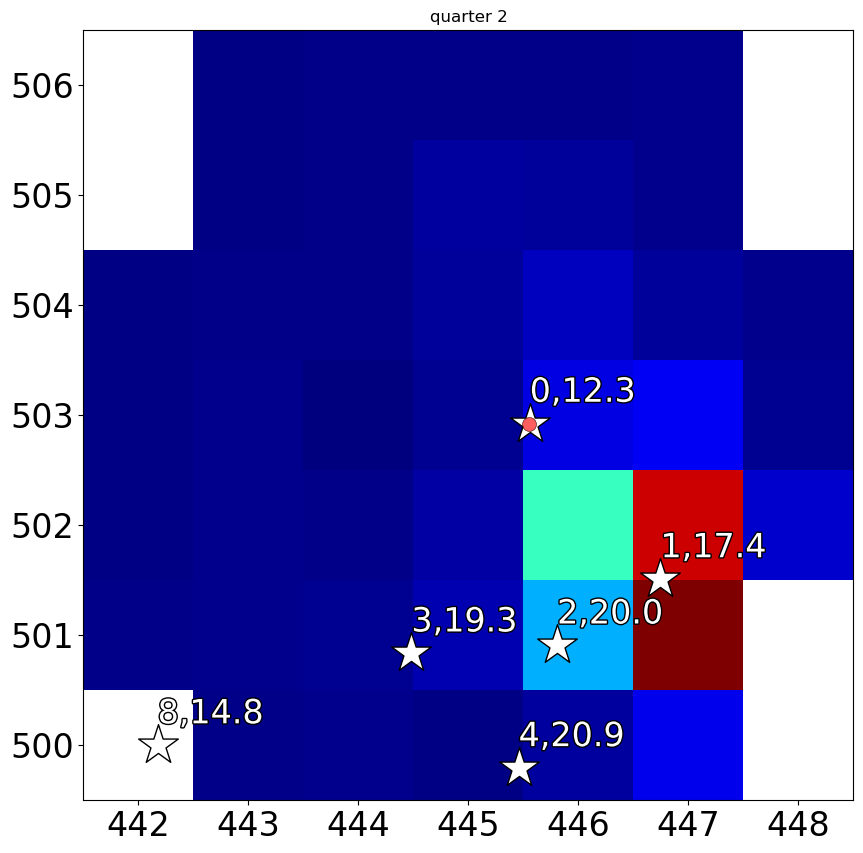

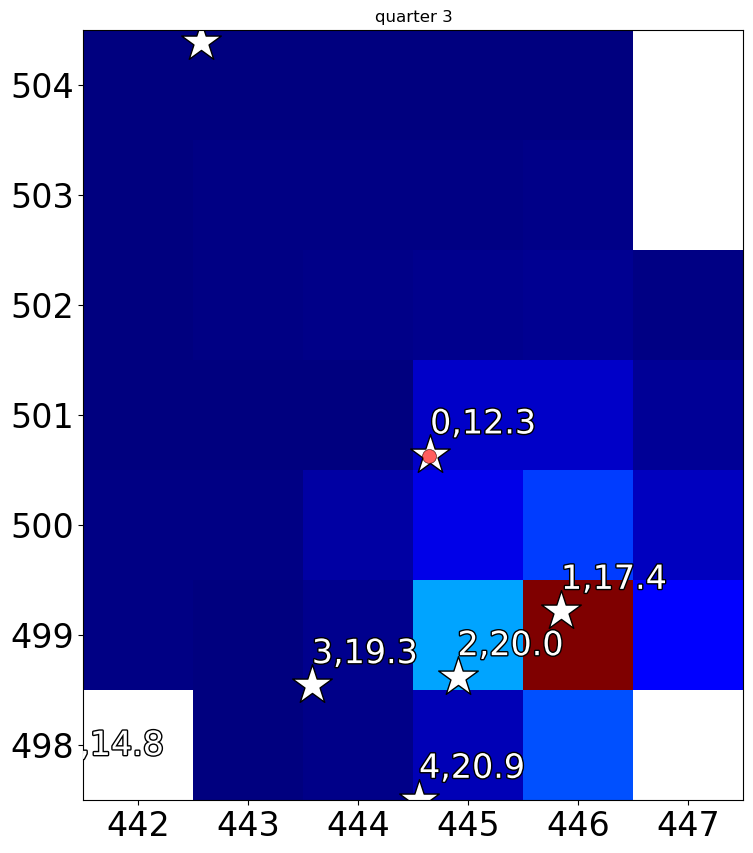

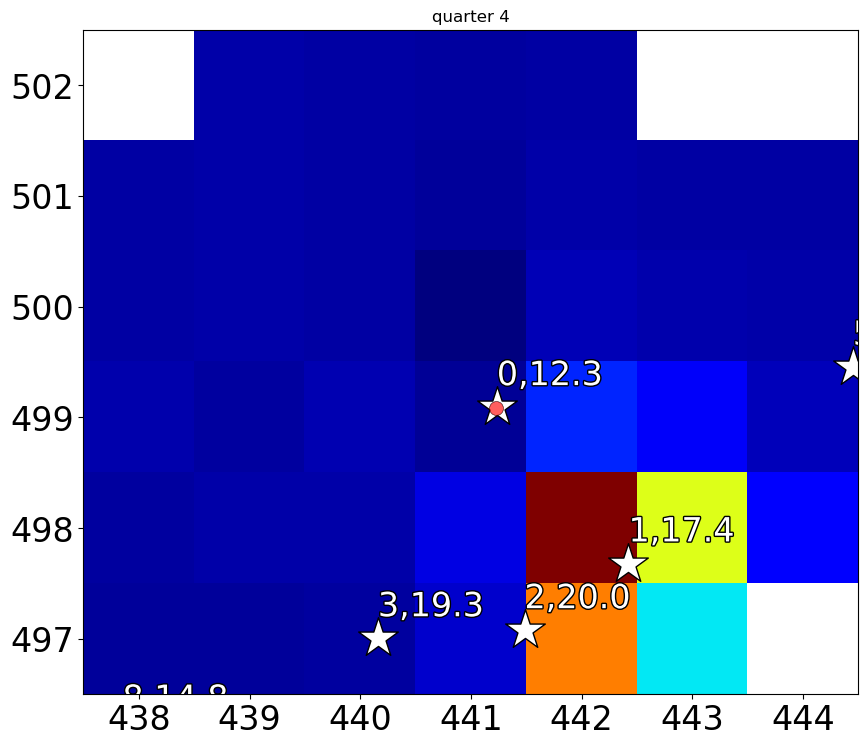

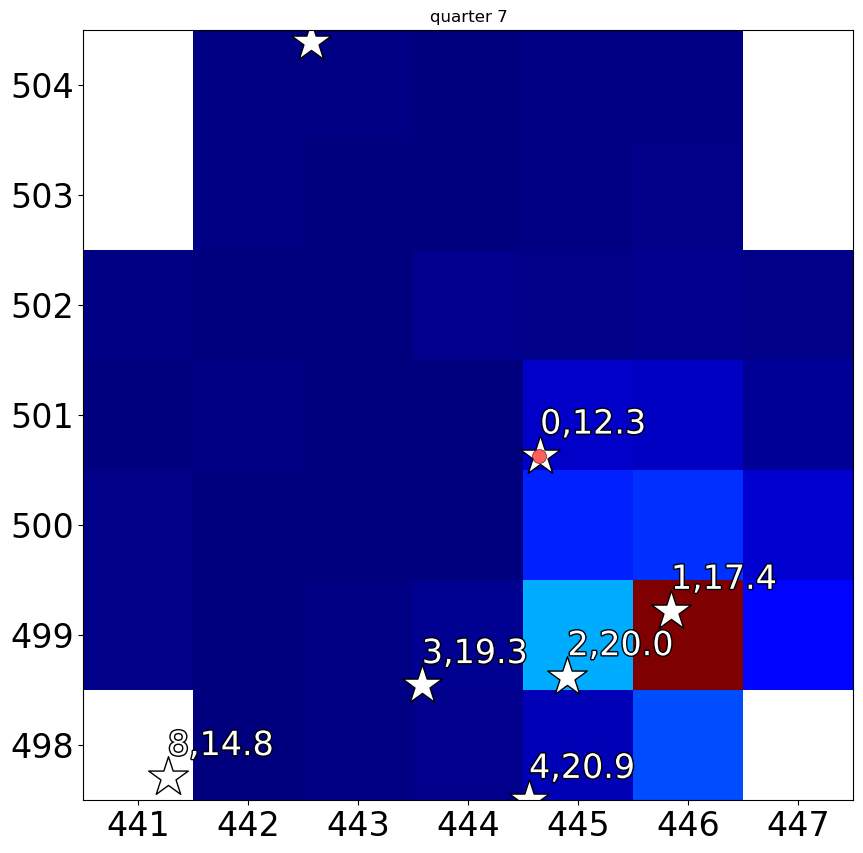

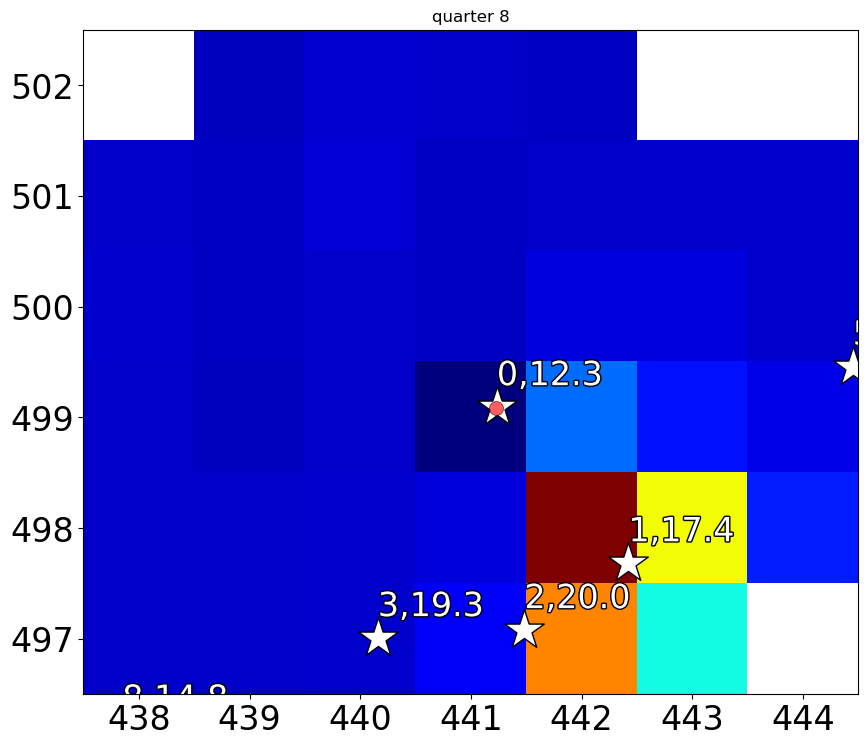

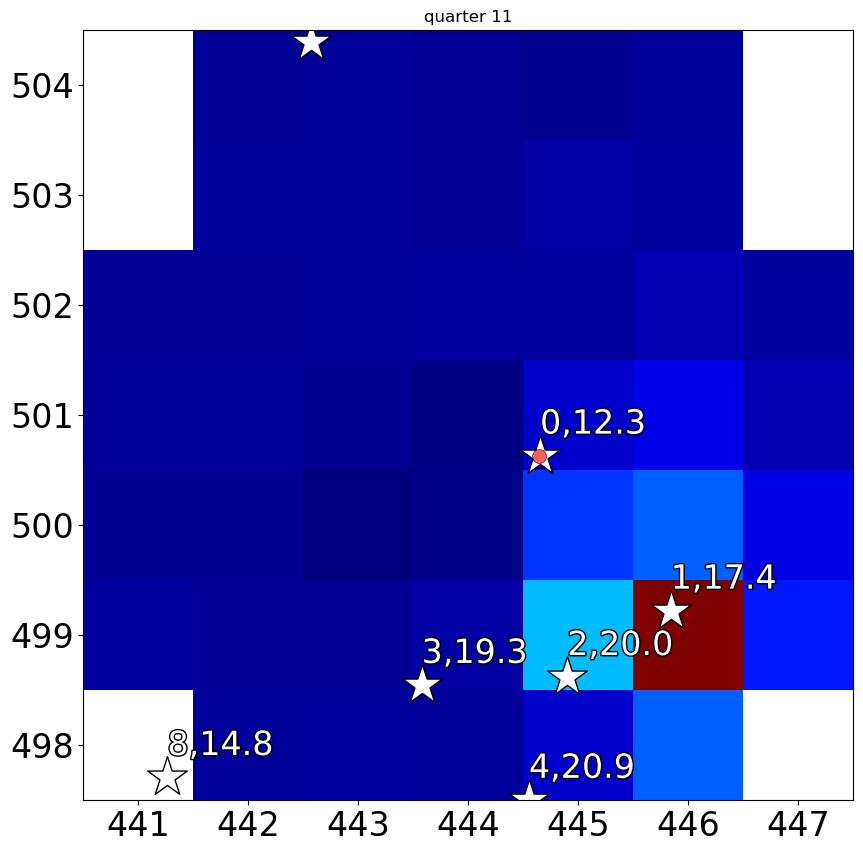

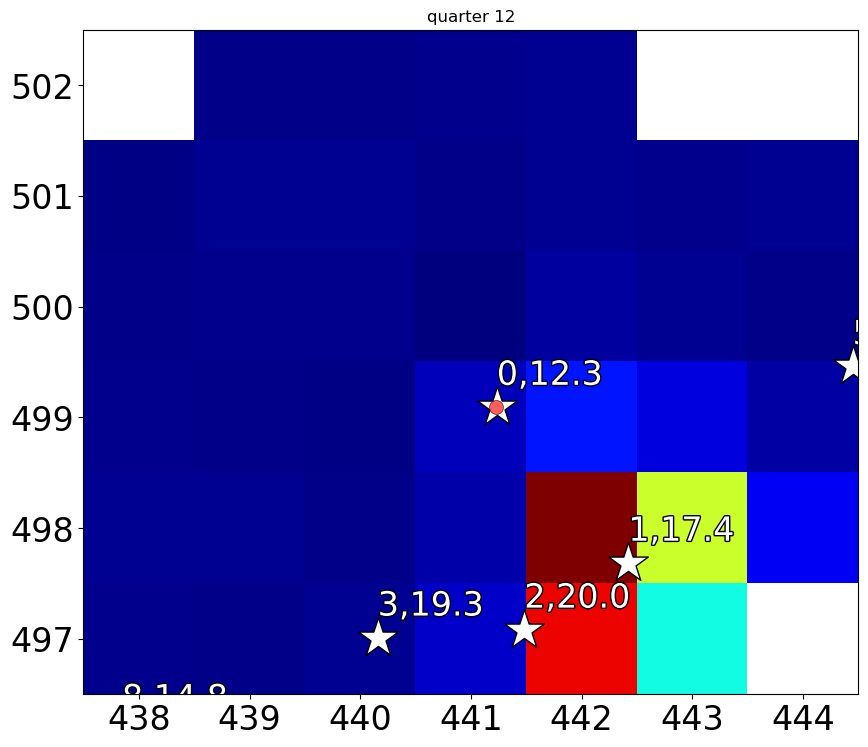

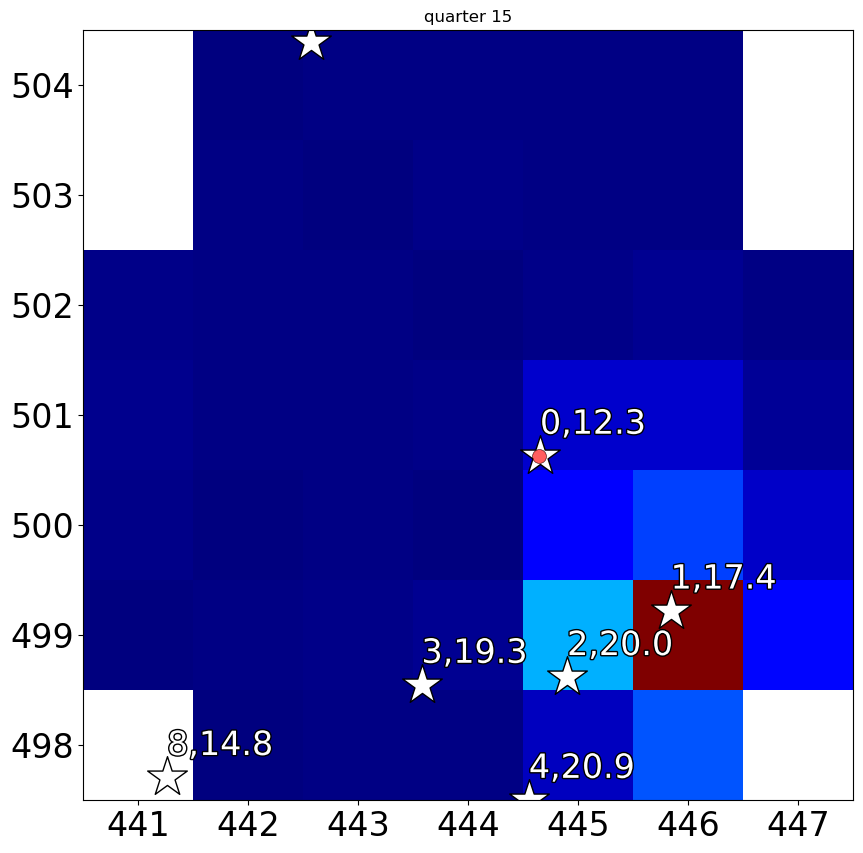

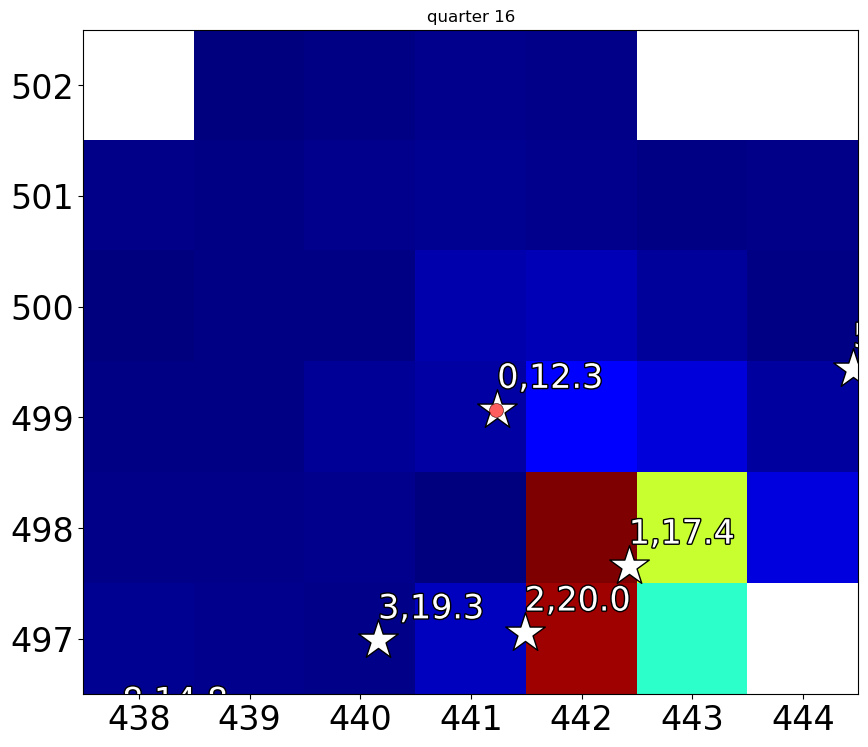

In [5]:
for q in range(len(haveQuarters)):
    quarterData = quarterDataList[q]
    app.draw_pix_image(allDiffImage[q], quarterData["extent"], quarterData["gaiaCatalog"])
    plt.title("quarter " + str(quarterDataList[q]["quarter"]))

/Volumes/meow/steve/work/tess/transit-APP/keplerApp.py:66: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize = (10,10));


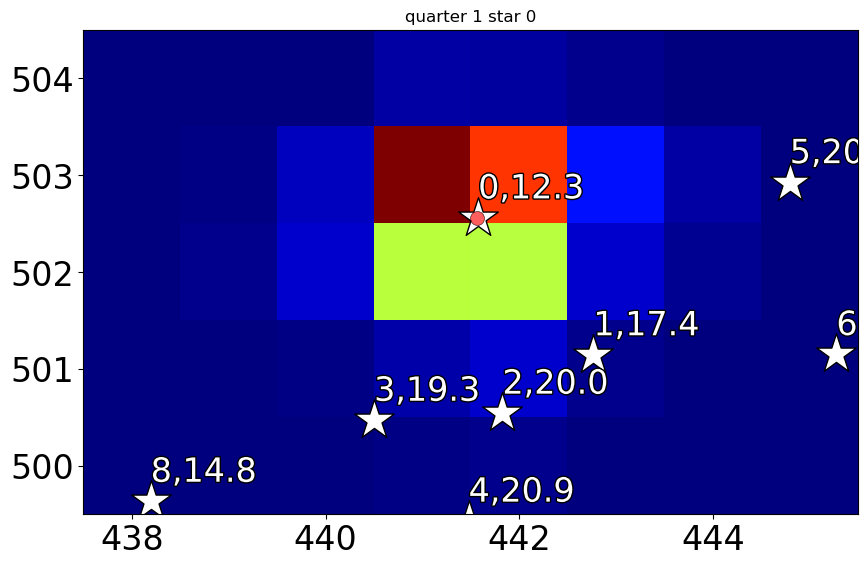

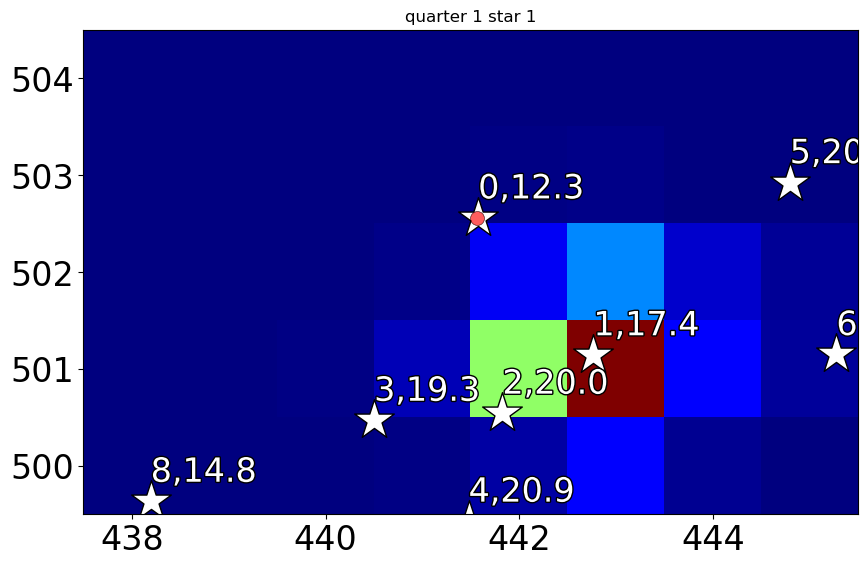

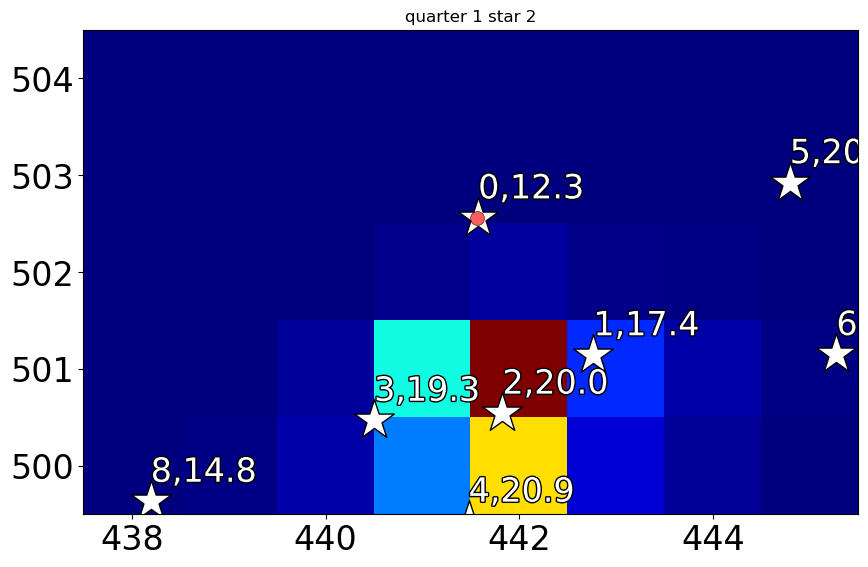

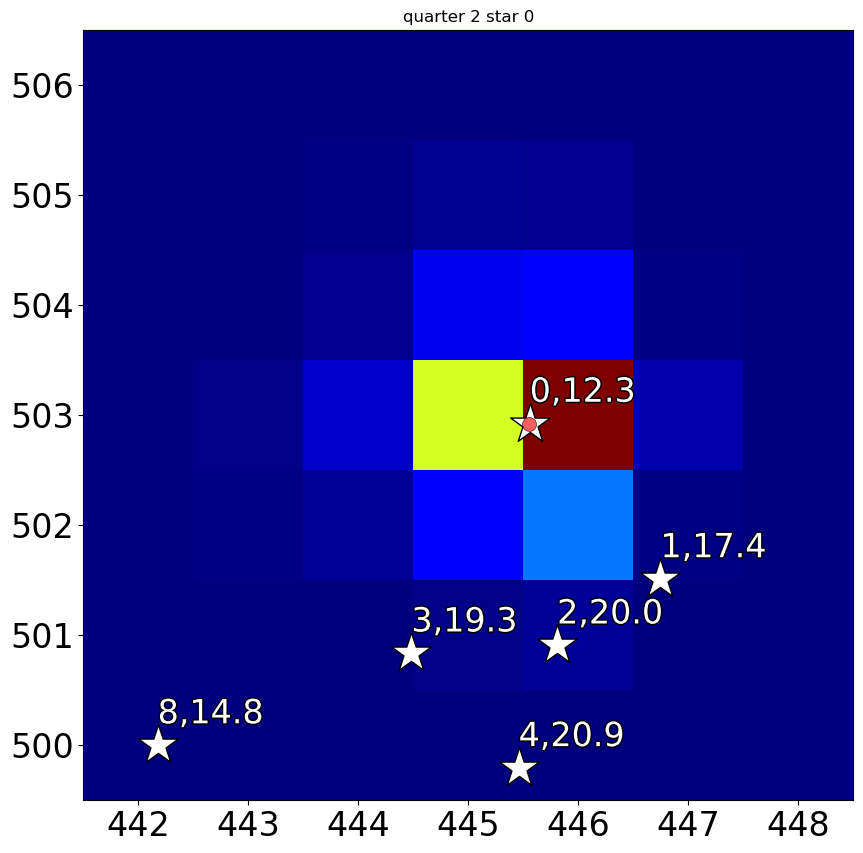

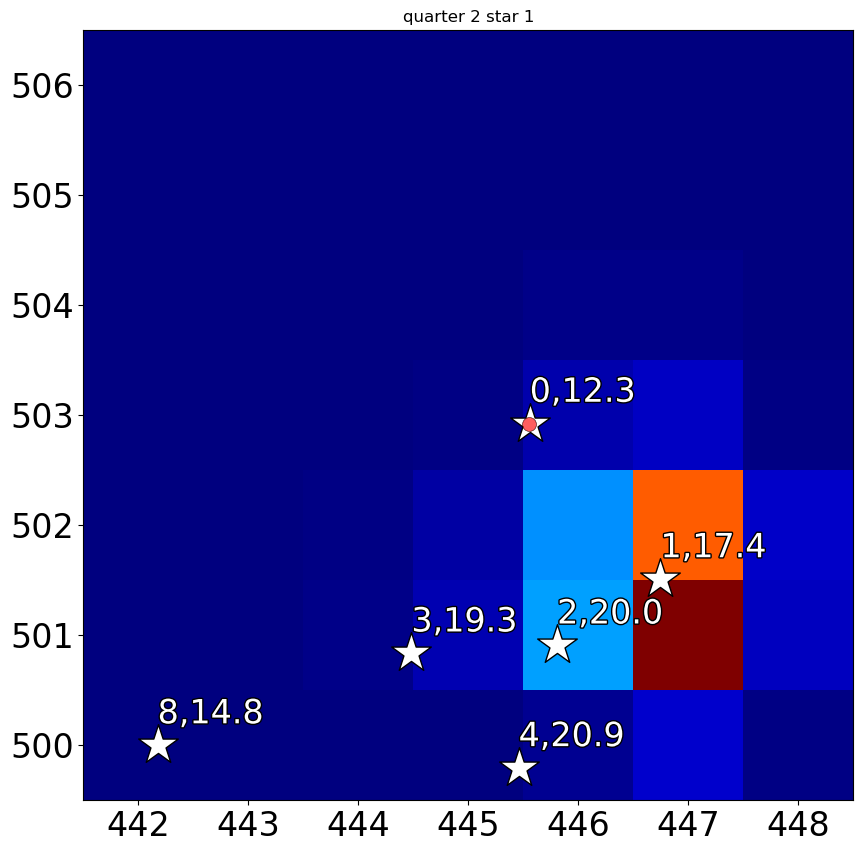

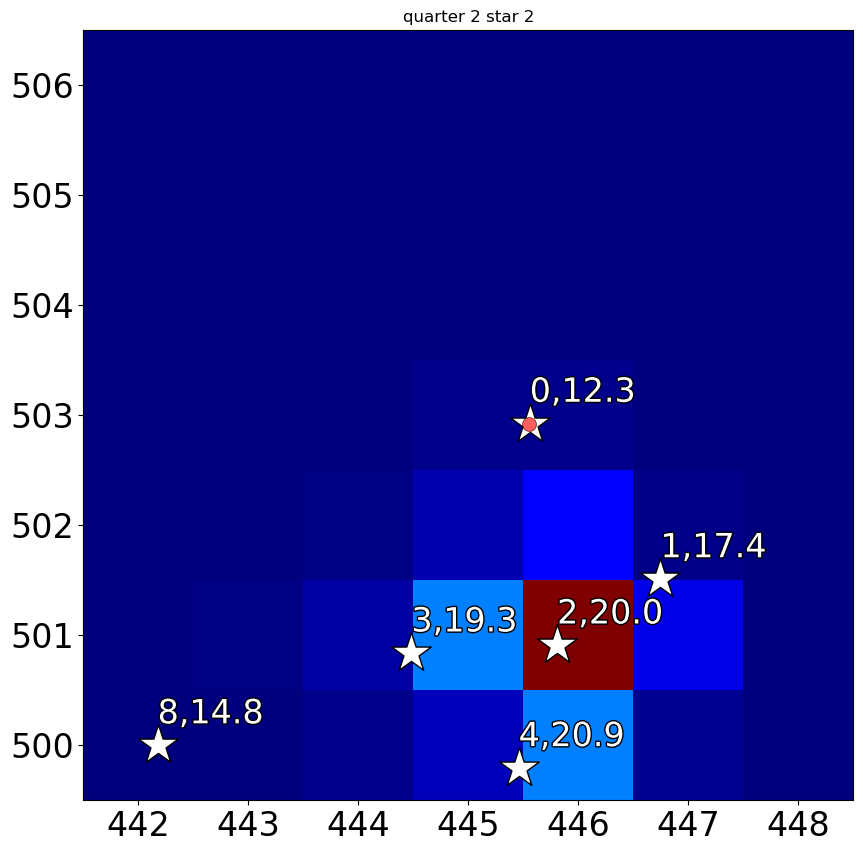

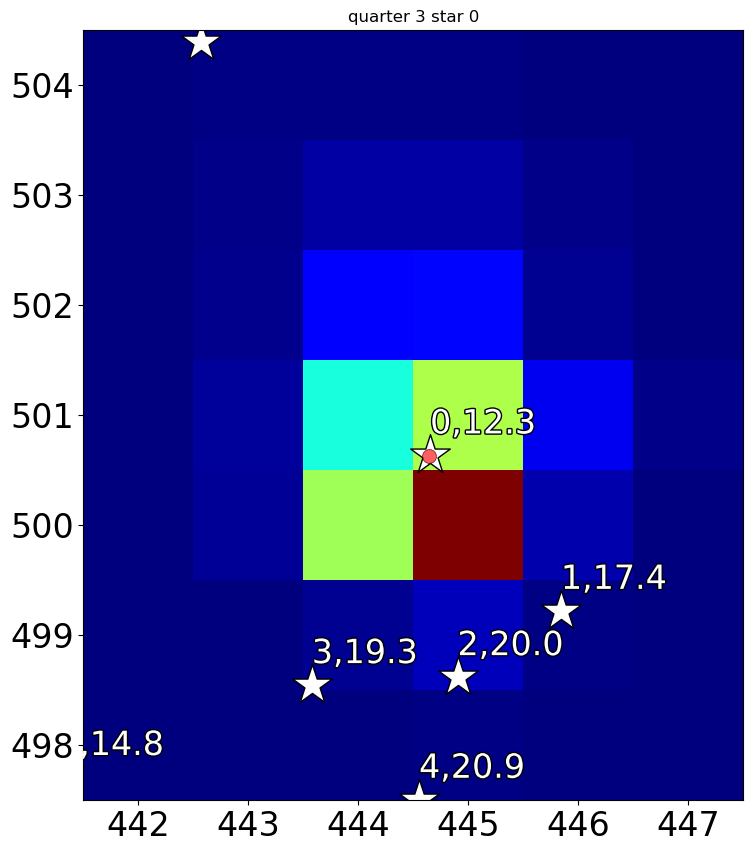

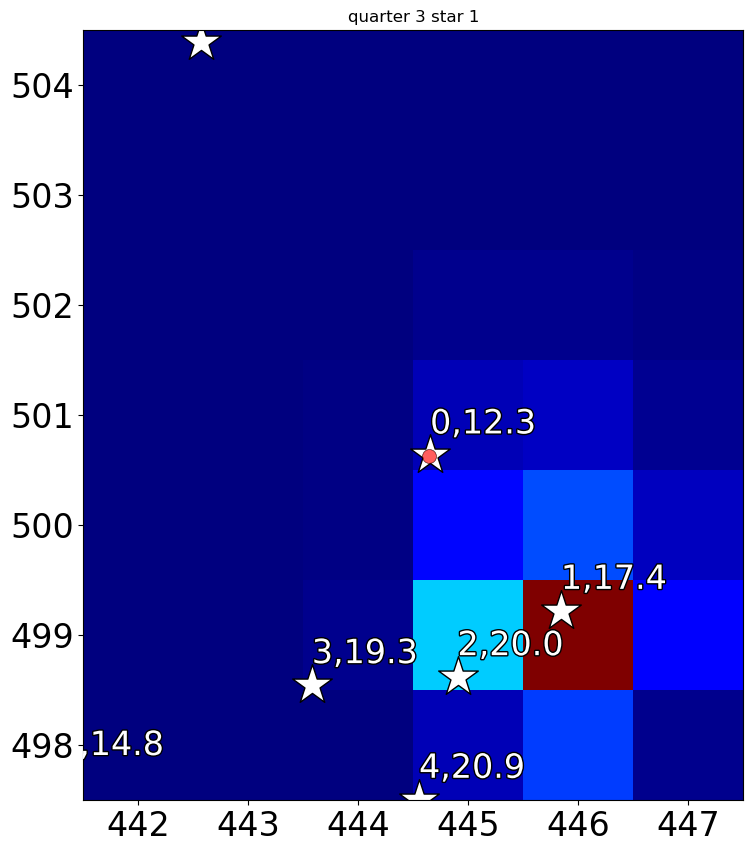

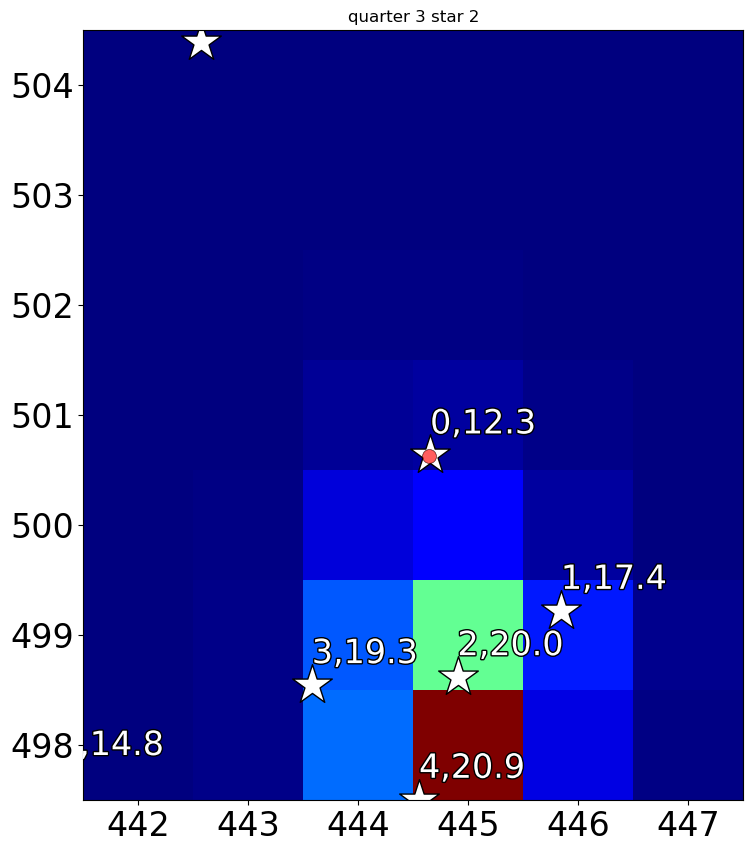

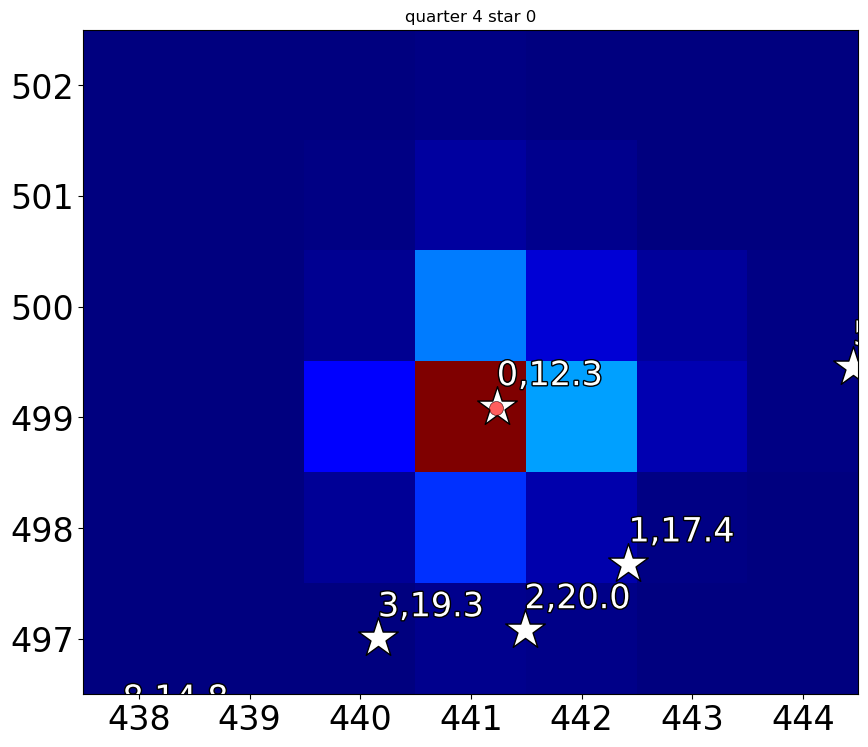

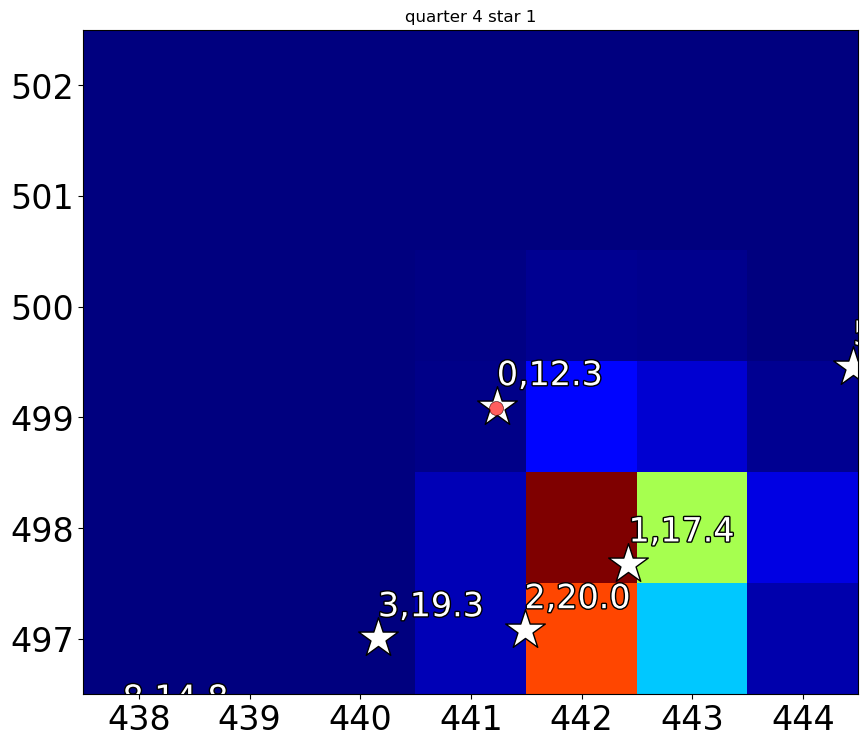

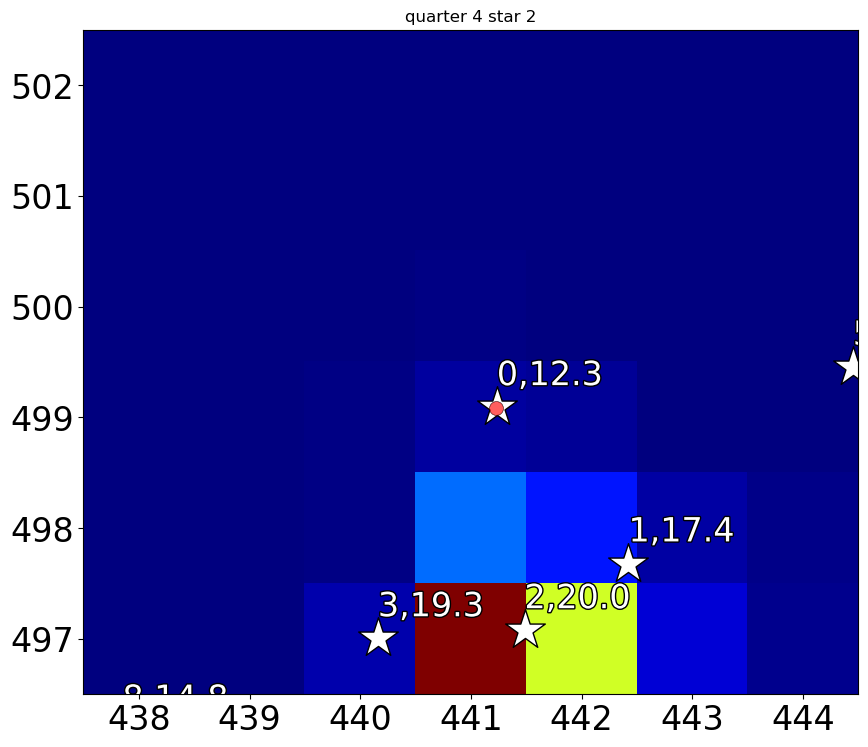

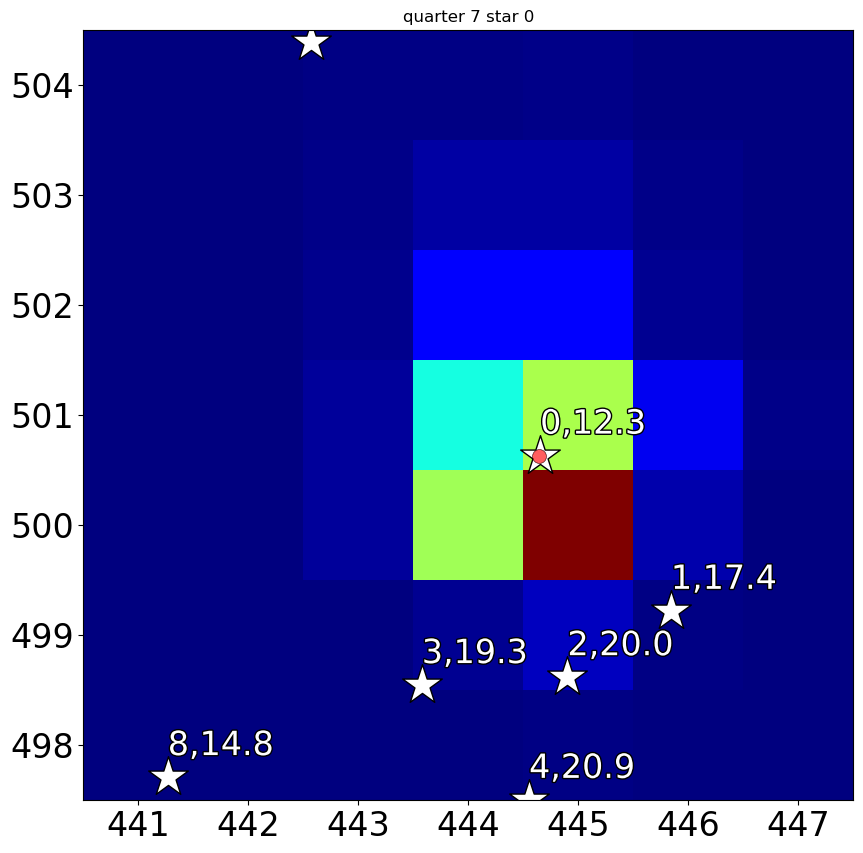

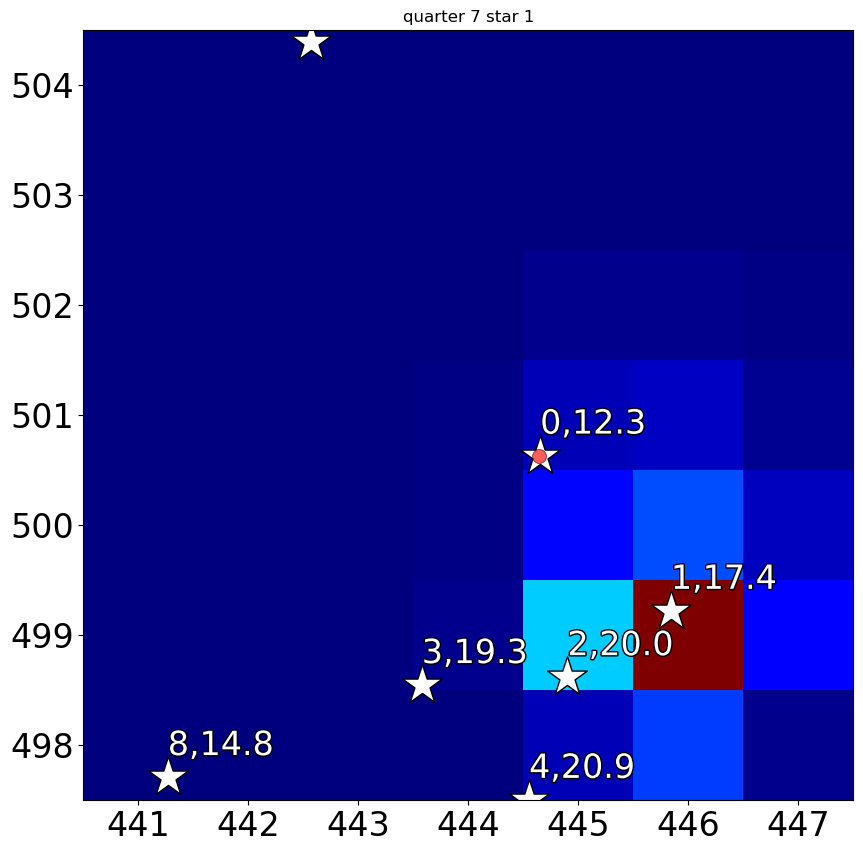

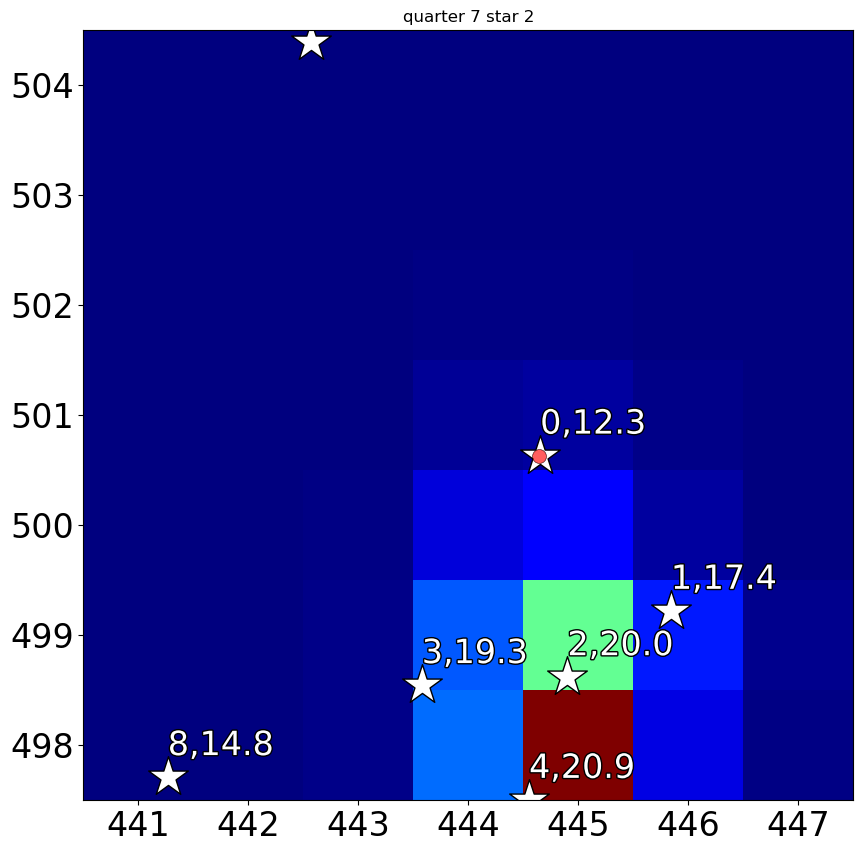

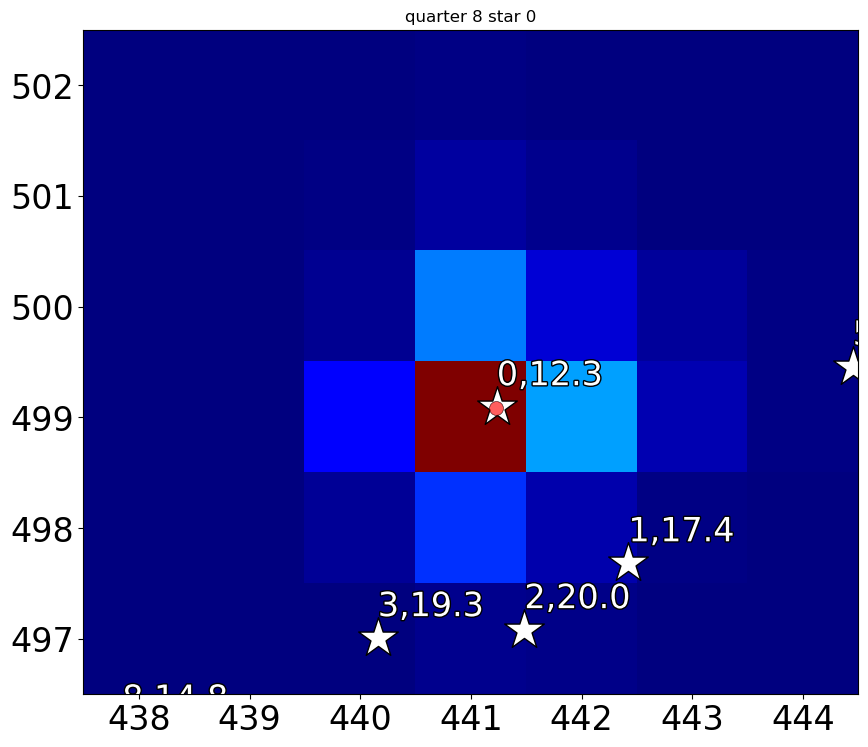

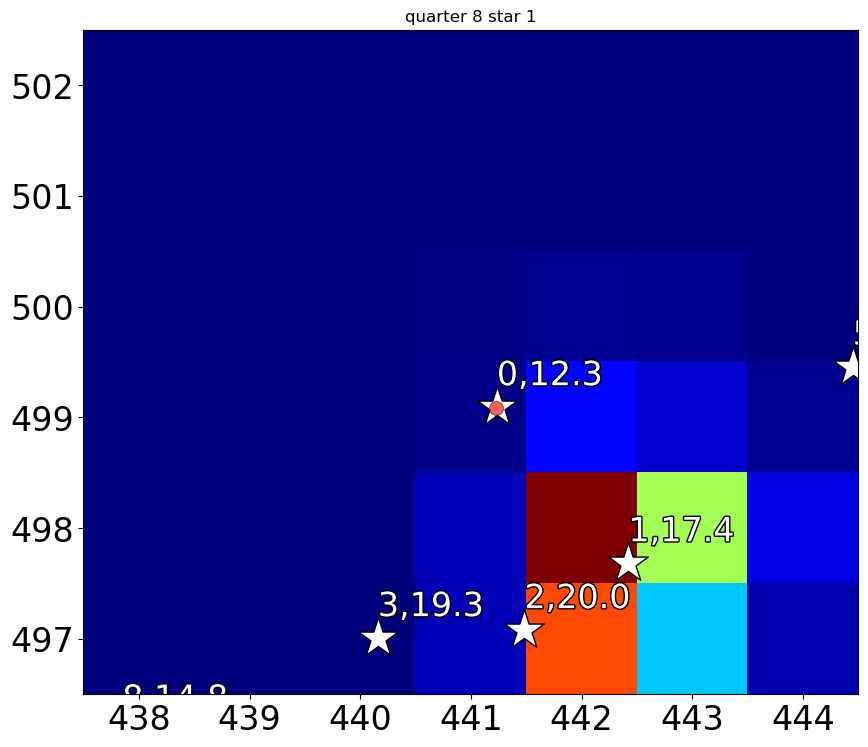

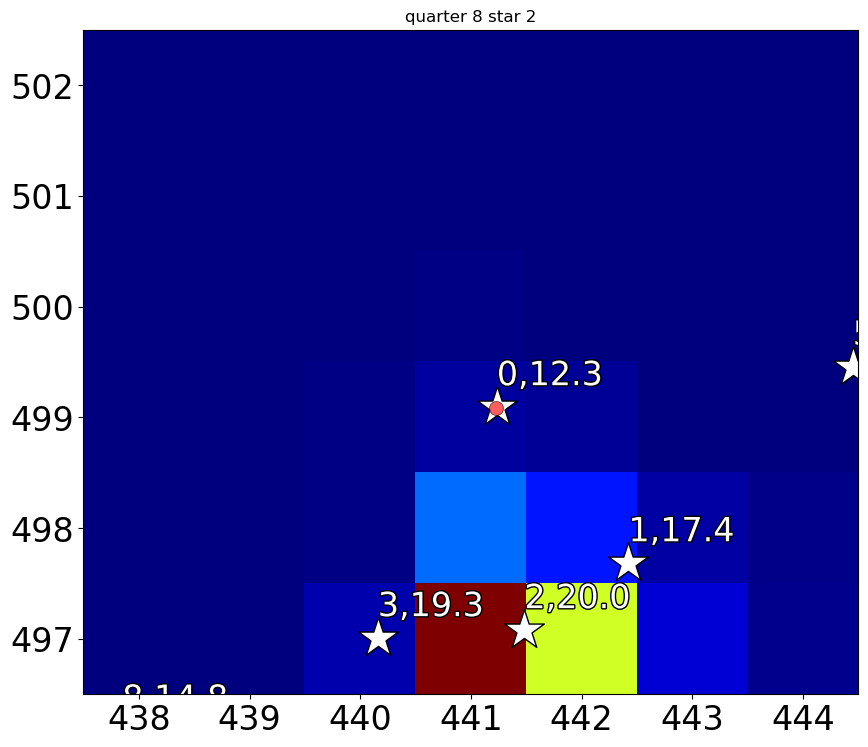

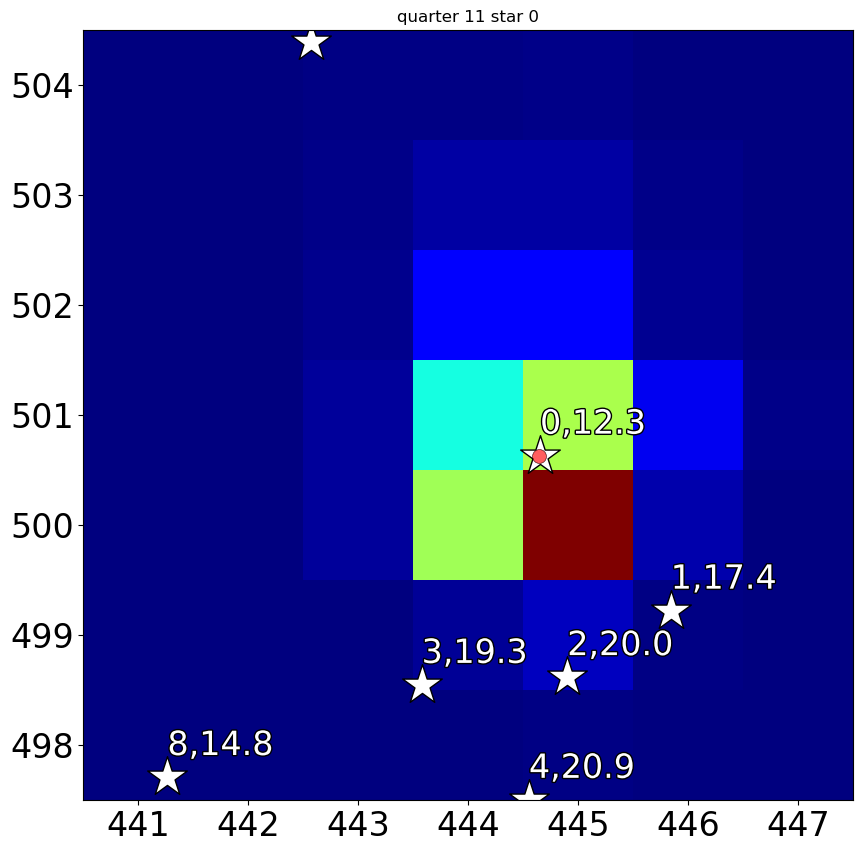

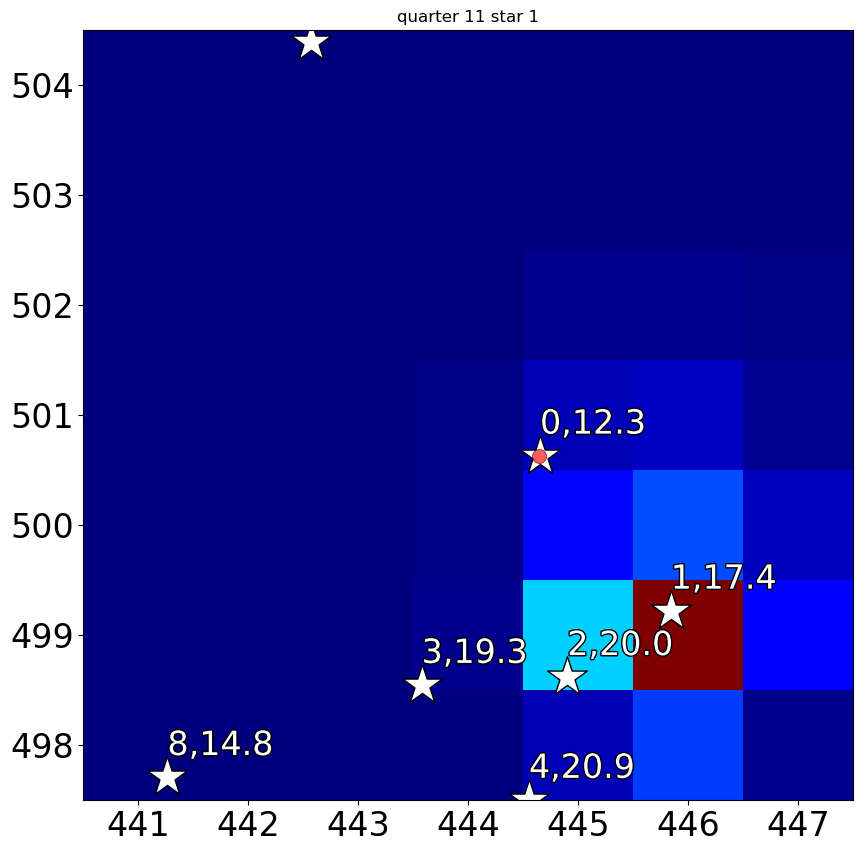

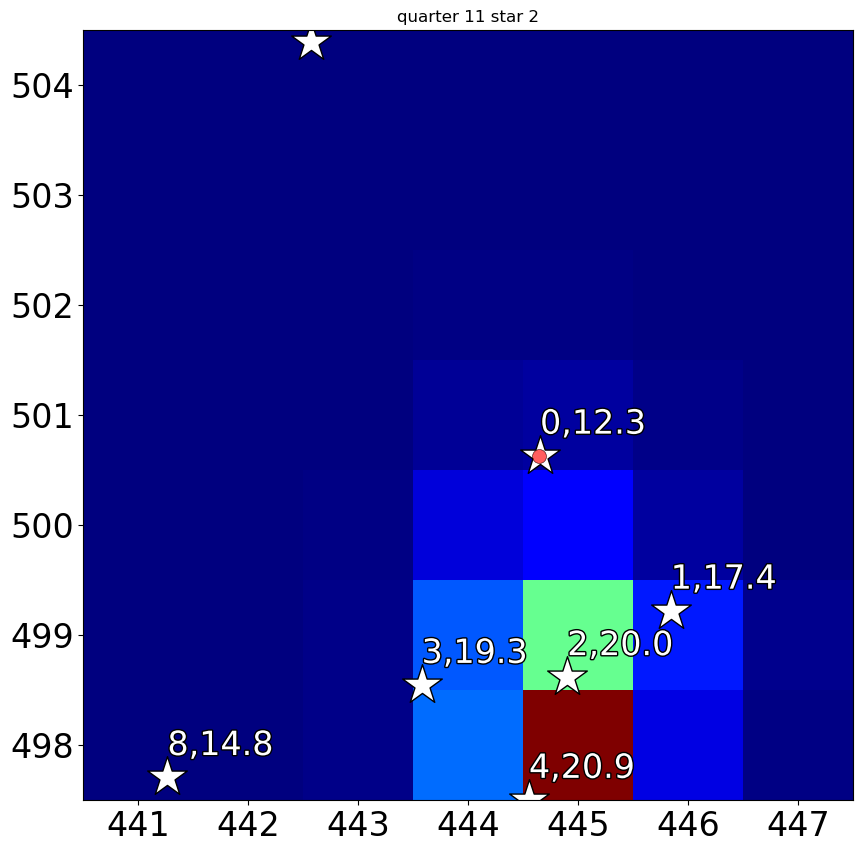

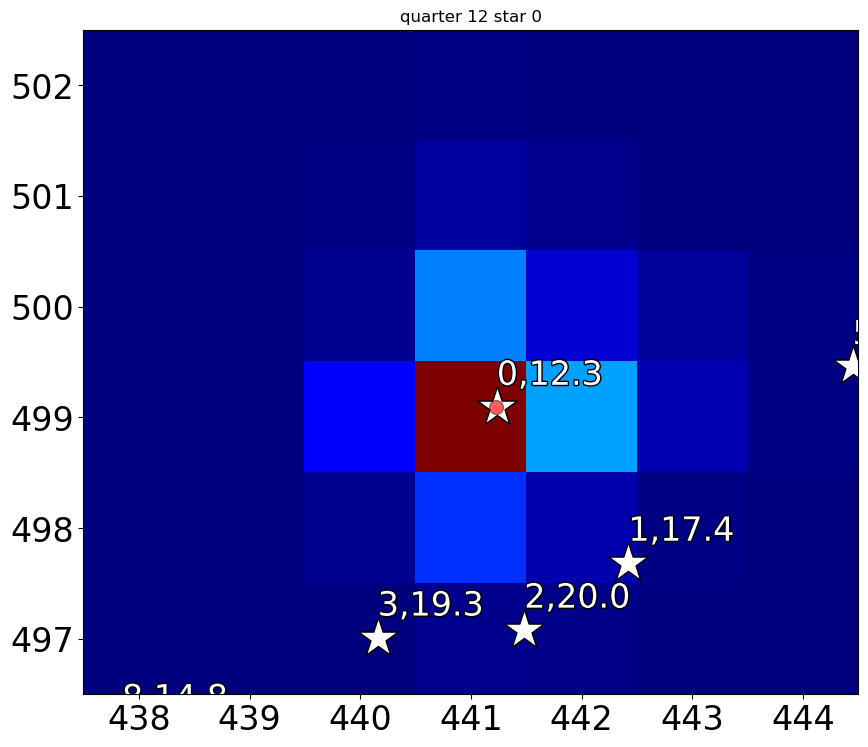

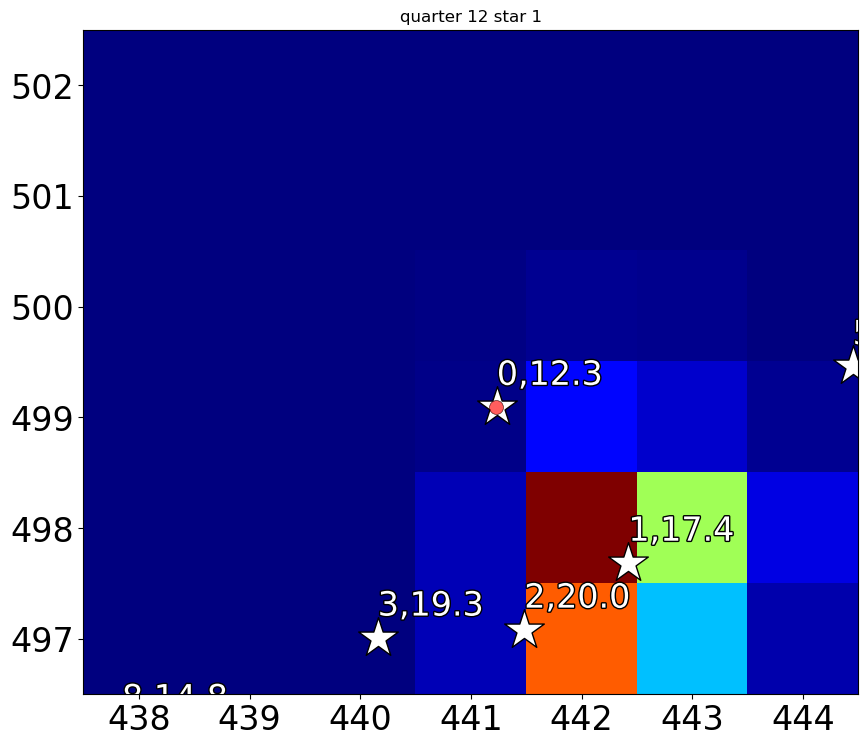

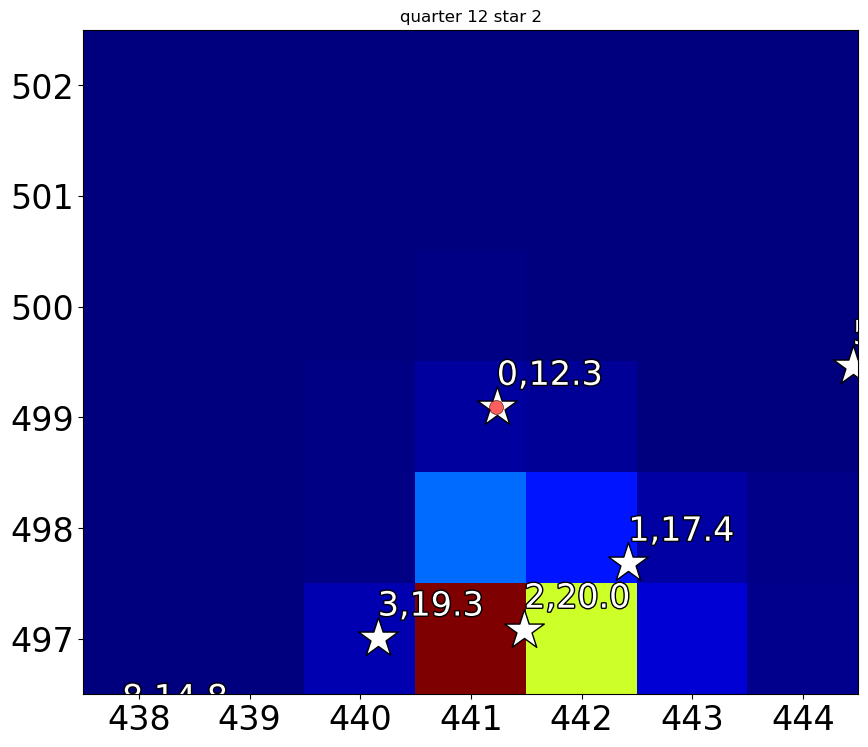

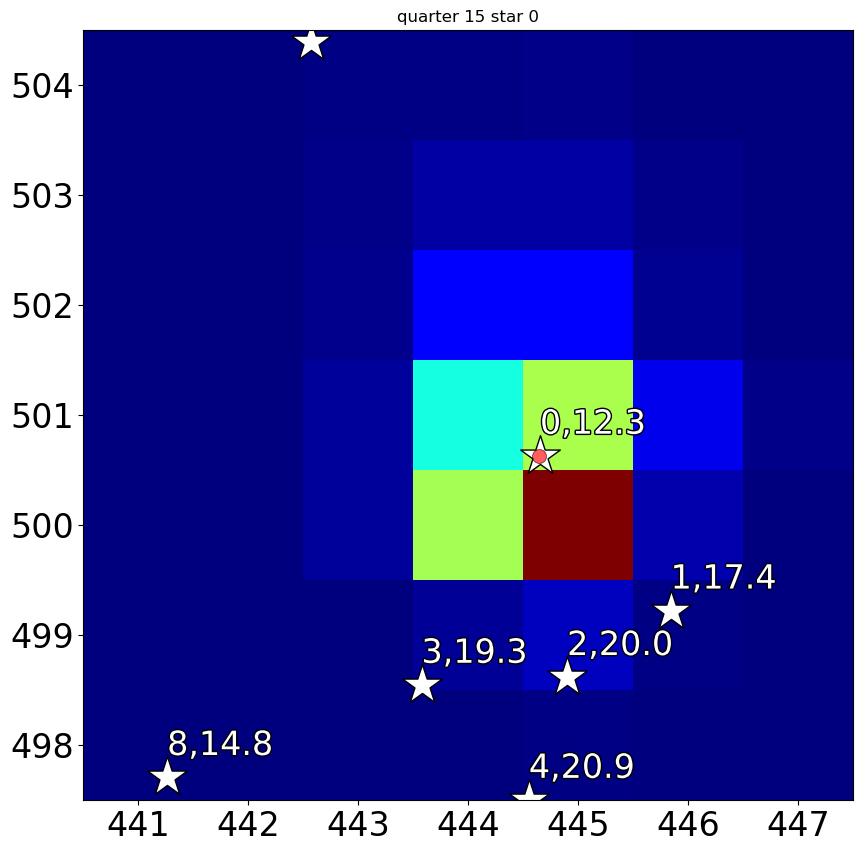

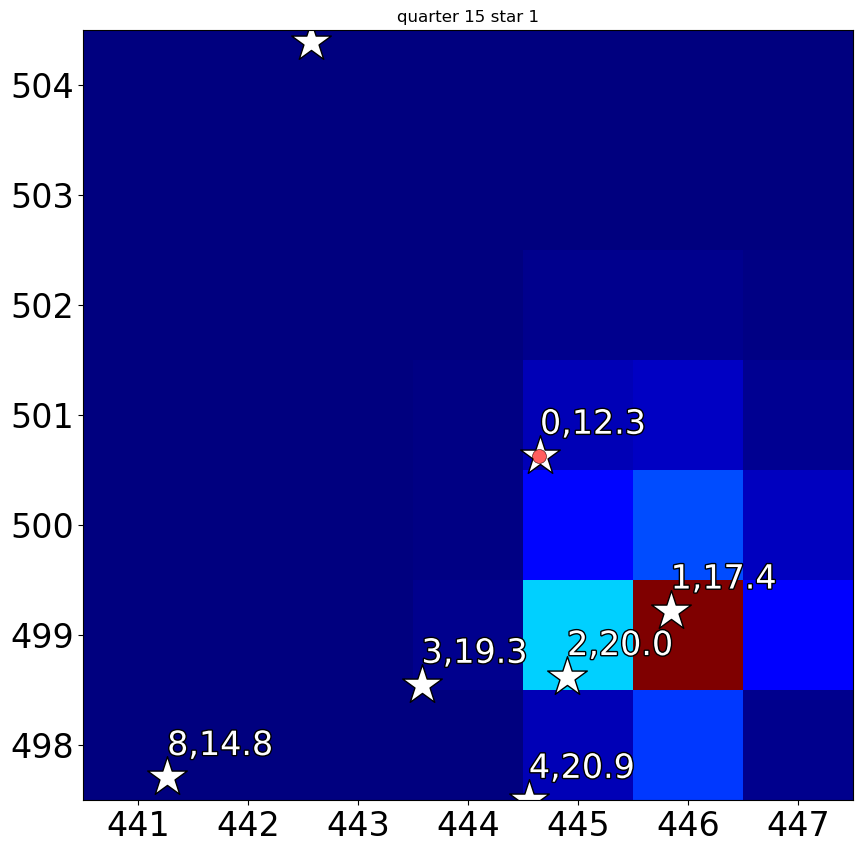

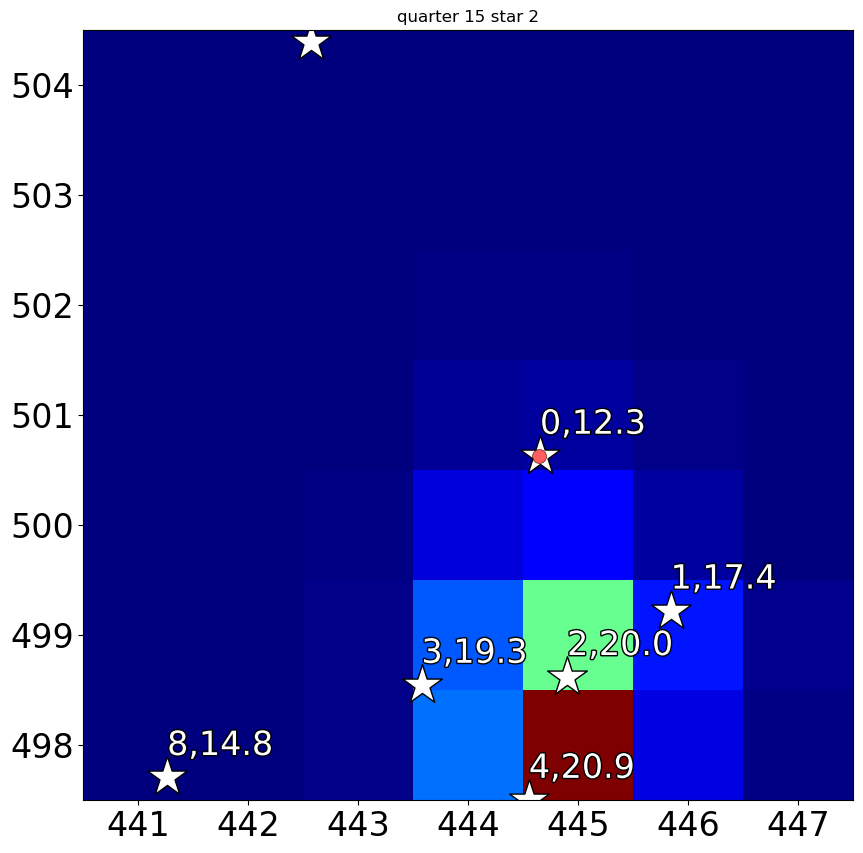

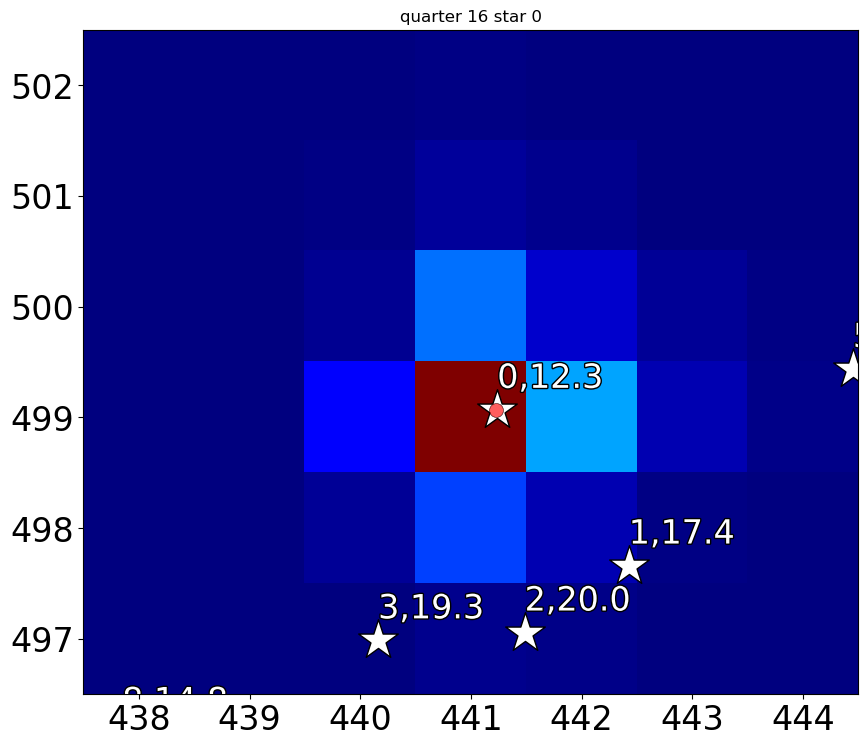

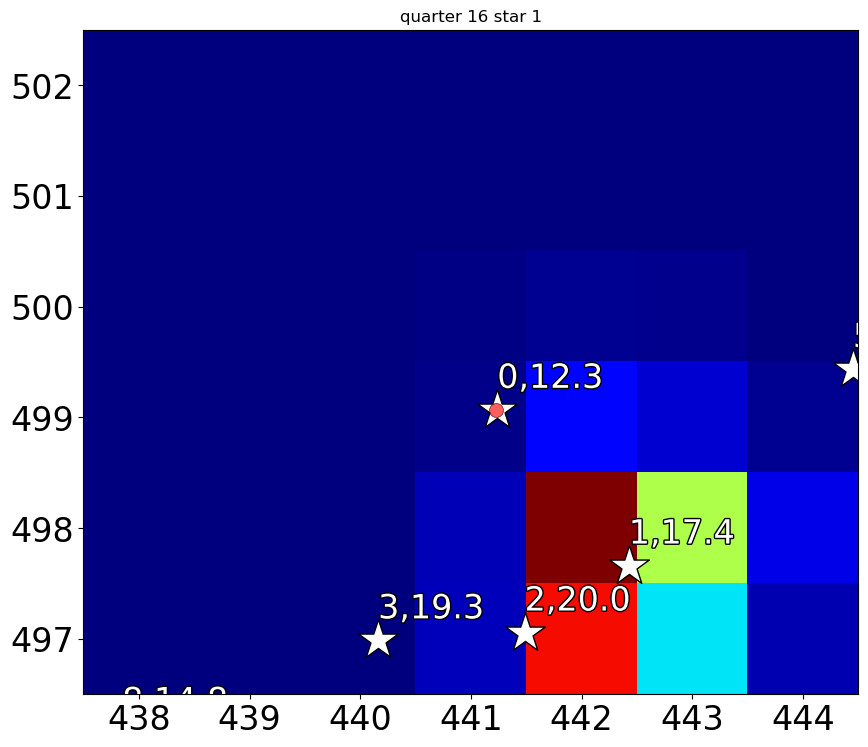

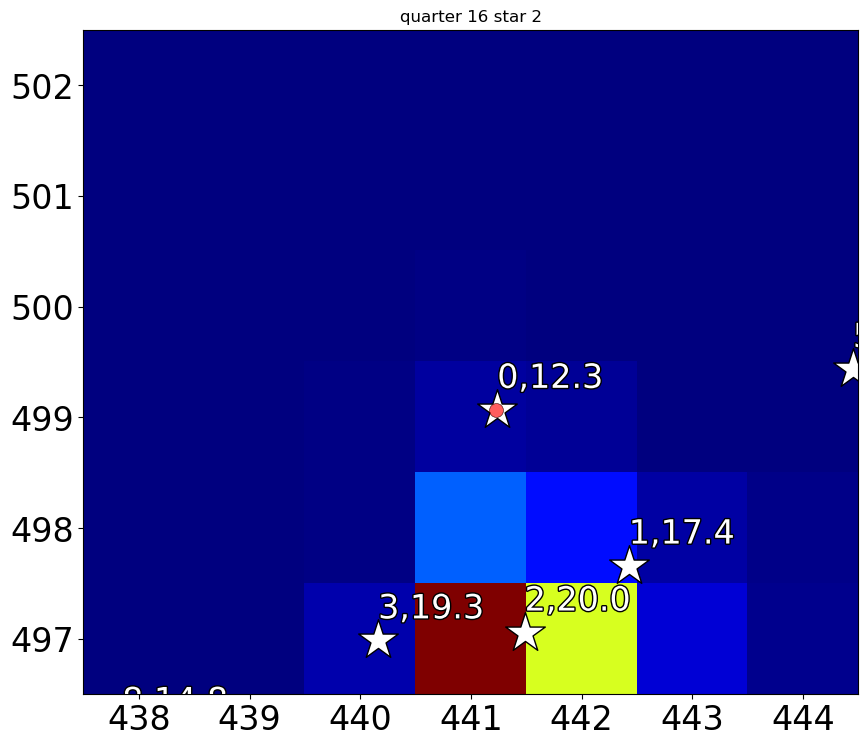

In [6]:
for q in range(len(haveQuarters)):
    quarterData = quarterDataList[q]
    for s in starList:
        app.draw_pix_image(allSimDiffImage[s][q], quarterData["extent"], quarterData["gaiaCatalog"])
        plt.title("quarter " + str(quarterDataList[q]["quarter"]) + " star " + str(s))

In [7]:
[allDiffImageFlat.shape, allDiffImageSigmaFlat.shape]

[(399,), (399,)]

In [8]:
# bayesian analysis of the close models
import pymc as pm

modelList = []
traceDict = {}
for starIndex in starList:
    with pm.Model() as model:
        model.name = str(starIndex)
        modelList.append(model)
        # scale = pm.Normal('scale', mu=1, sigma=100)
        # sigmaScale = pm.Normal('sigmaScale', mu=1, sigma=100)
        # scale = pm.HalfNormal('scale', sigma=10000)
        # sigmaScale = pm.HalfNormal('sigmaScale', sigma=10000)
        scale = pm.Uniform('scale', lower=0, upper=1000)
        sigmaScale = pm.Uniform('sigmaScale', lower=0, upper=1000)
        fvect = allSimDiffImageFlat[starIndex]

        fobs = pm.Normal('fobs', 
                         mu=scale*fvect, 
                         sigma=sigmaScale*allDiffImageSigmaFlat, 
                         observed=allDiffImageFlat)

        targetTrace = pm.sample(100000, tune=5000, cores=8, step = pm.Metropolis(), 
                                idata_kwargs={"log_likelihood": True})
        traceDict[model] = targetTrace


Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>Metropolis: [0::scale]
>Metropolis: [0::sigmaScale]
/opt/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/opt/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/opt/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/opt/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/opt/anaconda3/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/opt/a

Output()

Sampling 8 chains for 5_000 tune and 100_000 draw iterations (40_000 + 800_000 draws total) took 39 seconds.
Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>Metropolis: [1::scale]
>Metropolis: [1::sigmaScale]


Output()

Sampling 8 chains for 5_000 tune and 100_000 draw iterations (40_000 + 800_000 draws total) took 39 seconds.
Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>Metropolis: [2::scale]
>Metropolis: [2::sigmaScale]


Output()

Sampling 8 chains for 5_000 tune and 100_000 draw iterations (40_000 + 800_000 draws total) took 39 seconds.


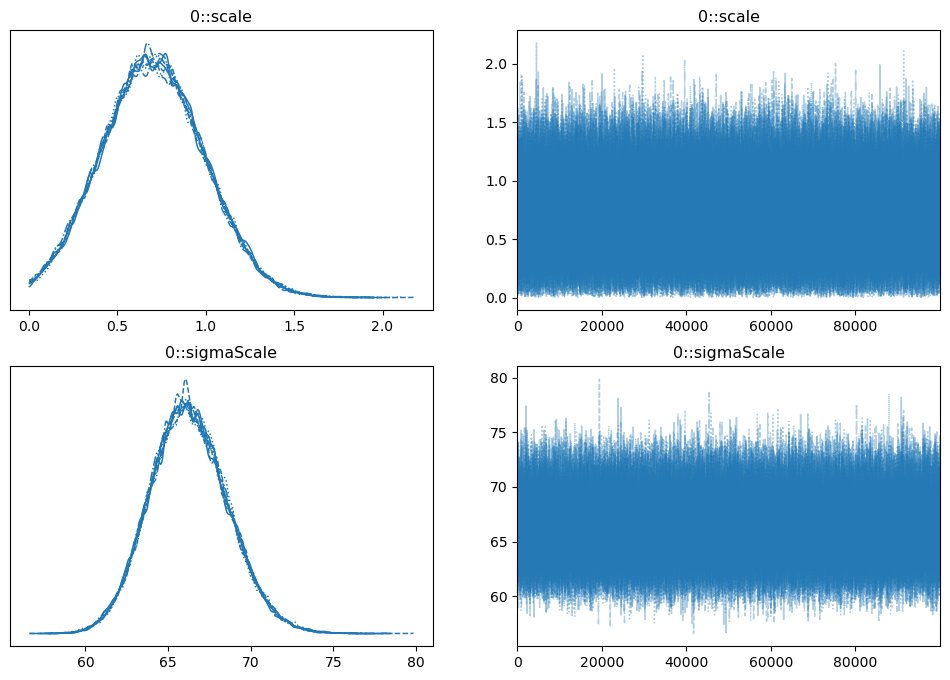

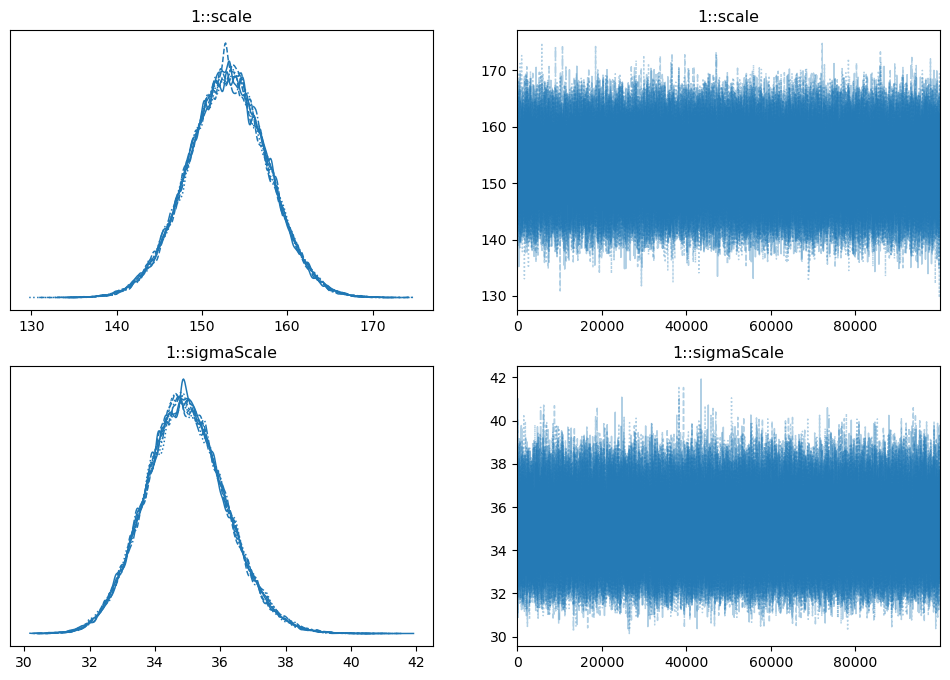

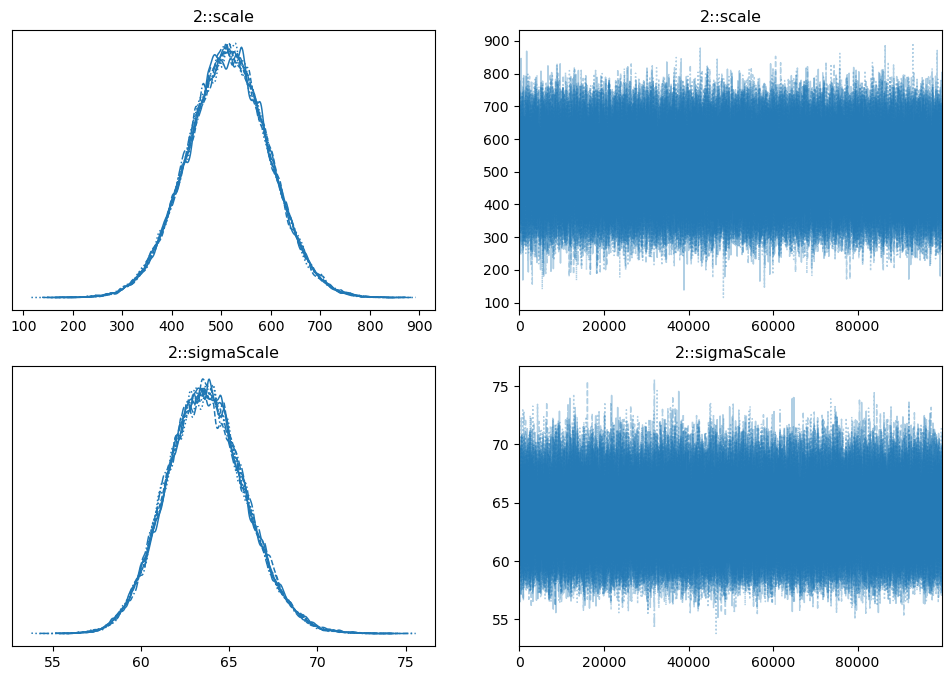

In [9]:
for s in range(len(starList)):
    pm.plot_trace(traceDict[modelList[s]], var_names=[str(s) + '::scale', str(s) + '::sigmaScale'], figsize=(12,8));


In [10]:
# dfwaic = pm.compare({onTarget: targetTrace, diffImage1: diffTrace1, diffImage2: diffTrace2}, ic='WAIC')
dfwaic = pm.compare(traceDict, ic='LOO', method="BB-pseudo-BMA")
dfwaic.index = [k.name for k,v in dfwaic.iterrows()]
dfwaic

/opt/anaconda3/lib/python3.11/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/anaconda3/lib/python3.11/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/anaconda3/lib/python3.11/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: ove

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
1,0,-1483.874190,5.791219,0.000000,1.000000e+00,34.586061,0.000000,False,log
2,1,-1724.835512,8.464792,240.961322,3.686724e-59,36.876604,41.238517,False,log
0,2,-1739.564058,6.470759,255.689867,1.823763e-66,37.384076,42.003524,False,log


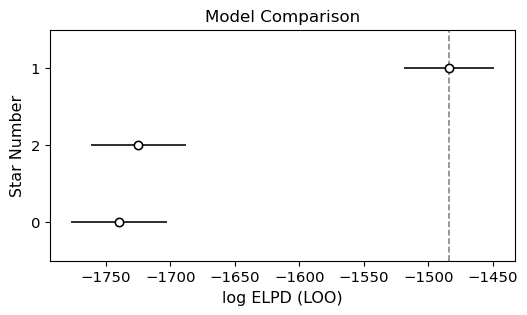

In [11]:
pm.plot_compare(dfwaic, insample_dev=False);
# plt.xlabel("log LOO")
plt.xlabel("log ELPD (LOO)")
plt.ylabel("Star Number")
plt.title("Model Comparison")
# plt.title(koiName)
plt.savefig(koiName + "_resultComparison.pdf", bbox_inches='tight')

In [12]:
for s in range(len(modelList)):
    mName = modelList[s].name + "::scale"
    post = traceDict[modelList[s]].posterior[mName][0].values
    print(modelList[s].name + " scale: "
          + str(np.round(np.mean(post),4)) + " +- "
          + str(np.round(np.std(post),4)))
    print(modelList[s].name + " estimated depth: "
          + str(np.round(standardDepth*np.mean(post),4)) + " +- "
          + str(np.round(standardDepth*np.std(post),4)))


0 scale: 0.7036 +- 0.285
0 estimated depth: 0.0007 +- 0.0003
1 scale: 153.0462 +- 4.7592
1 estimated depth: 0.153 +- 0.0048
2 scale: 513.7302 +- 82.636
2 estimated depth: 0.5137 +- 0.0826


In [13]:
quarterData["gaiaCatalog"]

solution_id,DESIGNATION,SOURCE_ID,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot,dist,correctedGaiaRa,correctedGaiaRaSigma,correctedGaiaDec,correctedGaiaDecSigma,gaiaSigma,targetMod,targetOut,targetRow,targetCol,flux,mod,out,row,col
,,,,yr,deg,mas,deg,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,,,deg,,,,,,,,deg,deg,deg,deg,,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,log(cm.s**-2),dex,,km / s,km / s,,mag,mag,,,,deg,deg,deg,deg,,,,,,,,,,,,,,,K,K,K,log(cm.s**-2),log(cm.s**-2),log(cm.s**-2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,,,,,,,,,,,,,,,
int64,object,int64,int64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,int16,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float32,int16,int16,int16,float32,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32

In [14]:
starList

[0, 1, 2]

In [15]:
allDiffImage[2].shape

(7, 6)

In [16]:
quarterDataList[3]

{'quarter': 4,
 'tpf': KeplerTargetPixelFile Object (ID: 4752451),
 'extent': (437.5, 444.5, 496.5, 502.5),
 'meanMjd': 55229.86437771773,
 'diffImageData': {'diffImage': array([[            nan,  1.26755934e-01,  4.03125470e-02,
          -2.34412560e-01, -1.03364211e-01,             nan,
                      nan],
         [ 7.83990713e-02,  2.33618956e-01, -3.20152870e-02,
          -4.94206355e-01,  1.62935697e-01, -5.32484788e-02,
          -1.49764428e-01],
         [ 4.33281385e-02,  1.50241705e-01, -5.09267954e-02,
          -2.13123498e+00,  9.42382812e-01,  4.77999174e-01,
           2.97006460e-01],
         [ 5.12699714e-01, -2.32593243e-01,  8.02922175e-01,
          -7.40384615e-01,  8.13551683e+00,  4.60424805e+00,
           1.18481211e+00],
         [-1.73073402e-01,  1.22350253e-01,  2.70136907e-01,
           3.46901292e+00,  6.07592586e+01,  3.69213163e+01,
           5.65818493e+00],
         [-5.36921575e-01, -4.71221924e-01, -2.65254094e-01,
           2.1565223

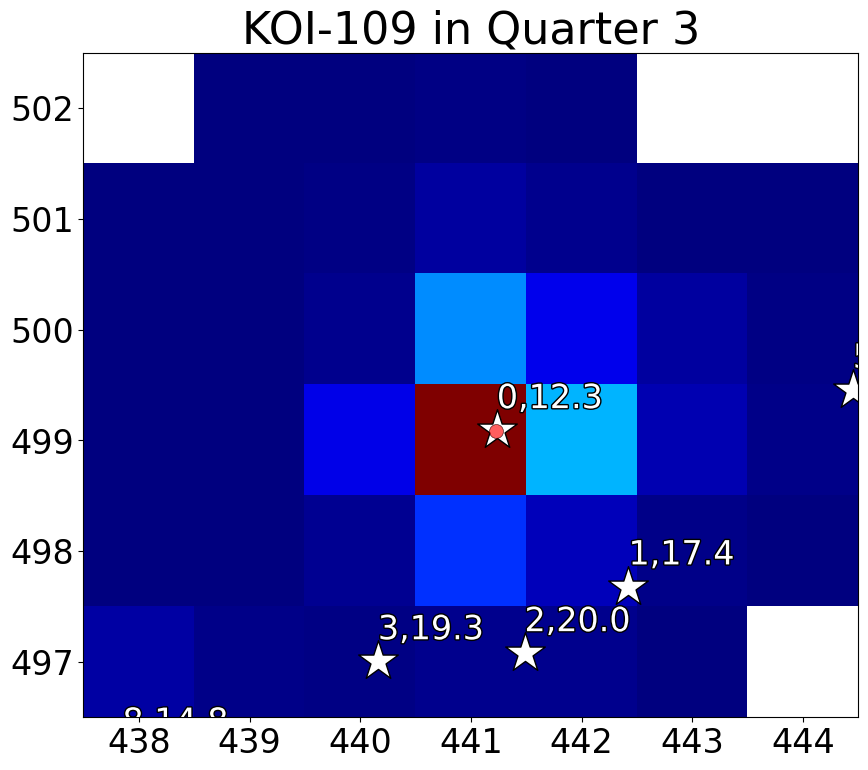

In [17]:
q = 3
quarterData = quarterDataList[q]
app.draw_pix_image(quarterData['diffImageData']["meanOutTransit"], quarterData["extent"], quarterData["gaiaCatalog"])
plt.title("KOI-109 in Quarter " + str(q), fontsize=32)

plt.savefig(koiName + "_starImage.pdf", bbox_inches='tight')

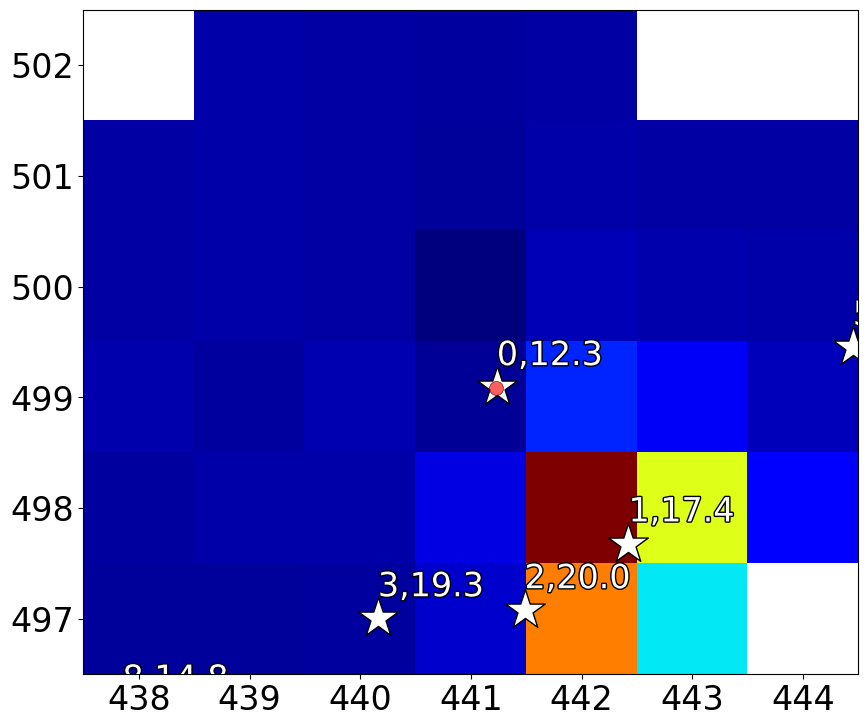

In [17]:
q = 3
quarterData = quarterDataList[q]
app.draw_pix_image(allDiffImage[q], quarterData["extent"], quarterData["gaiaCatalog"])

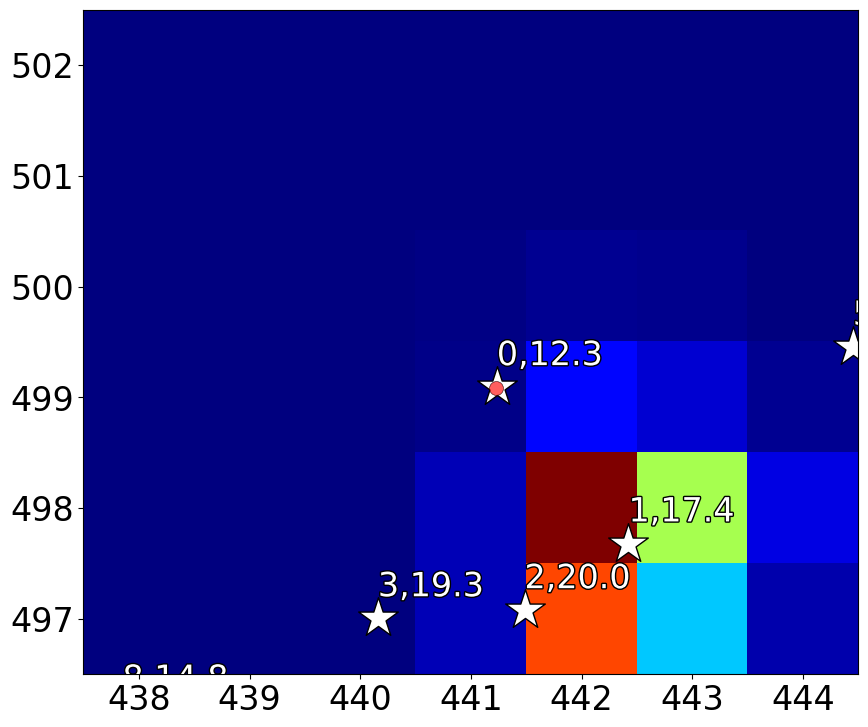

In [18]:
app.draw_pix_image(allSimDiffImage[1][q], quarterData["extent"], quarterData["gaiaCatalog"])


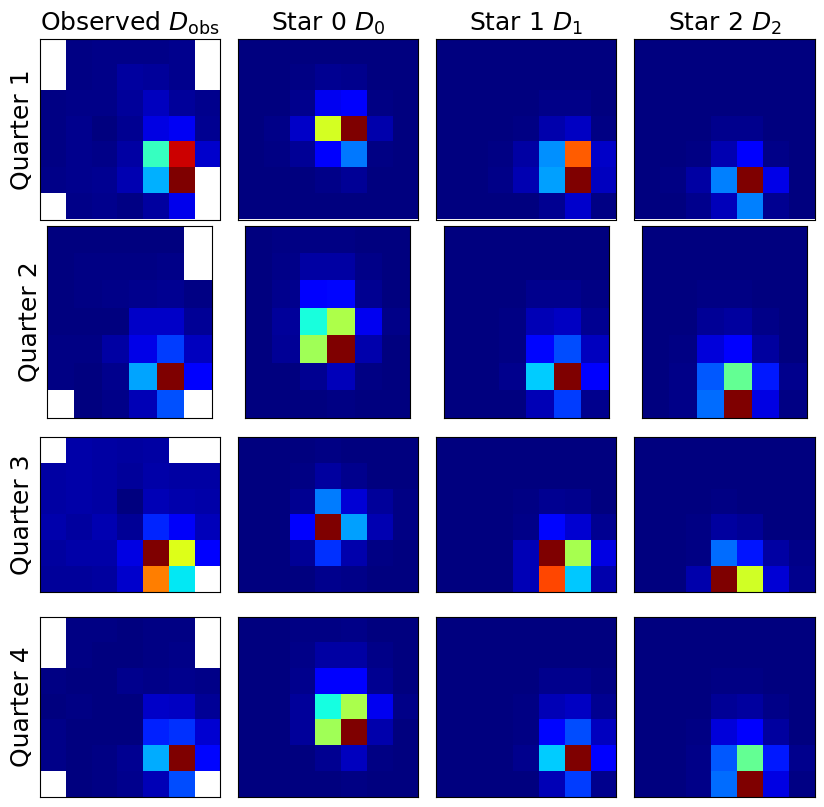

In [19]:
import matplotlib.gridspec as gridspec

gs = gridspec.GridSpec(4, 4, hspace=0, wspace=0.1)
# gs = gridspec.GridSpec(4, 4)
fig = plt.figure(figsize=(10, 10))
for q in [1,2,3,4]:
    quarterData = quarterDataList[q]
    ax1 = plt.subplot(gs[q-1, 0])
    plt.imshow(allDiffImage[q], cmap="jet", extent=quarterData["extent"])
    # plt.axis('off')
    # if q < 4:
    #     plt.gca().xaxis.set_major_locator(plt.NullLocator())
    plt.gca().xaxis.set_major_locator(plt.NullLocator())
    plt.gca().yaxis.set_major_locator(plt.NullLocator())
    if q == 1:
        plt.title("Observed $D_\mathrm{obs}$", fontsize=18)
    plt.ylabel("Quarter " + str(q), fontsize=18);

    for s in [0, 1, 2]:
        ax = plt.subplot(gs[q-1, s+1])
        plt.imshow(allSimDiffImage[s][q], cmap="jet", extent=quarterData["extent"])
        plt.gca().yaxis.set_major_locator(plt.NullLocator())
        plt.gca().xaxis.set_major_locator(plt.NullLocator())
        # if q < 4:
        #     plt.gca().xaxis.set_major_locator(plt.NullLocator())
        if q == 1:
            plt.title("Star " + str(s) + " $D_" + str(s) + "$", fontsize=18)
        # if s == 2:
        #     ax.yaxis.set_label_position("right")
        #     ax.set_ylabel("Quarter " + str(q), fontsize=18)
plt.savefig(koiName + "_imageGrid.pdf", bbox_inches='tight')